In [110]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [111]:
%cd /content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise

/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise


In [112]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
import time as time
import pandas as pd
import math
import copy
import os

In [113]:
from utils.dataset import GeneralDataset
from utils.network import MODEL
from utils.graphs import analyse_connectivity
from utils.plots import *
from utils.information_metrics import *

from sklearn.metrics import mutual_info_score

In [114]:
import sympy as sp

# Initialize SymPy printing in the notebook
#sp.init_printing(use_unicode=True)

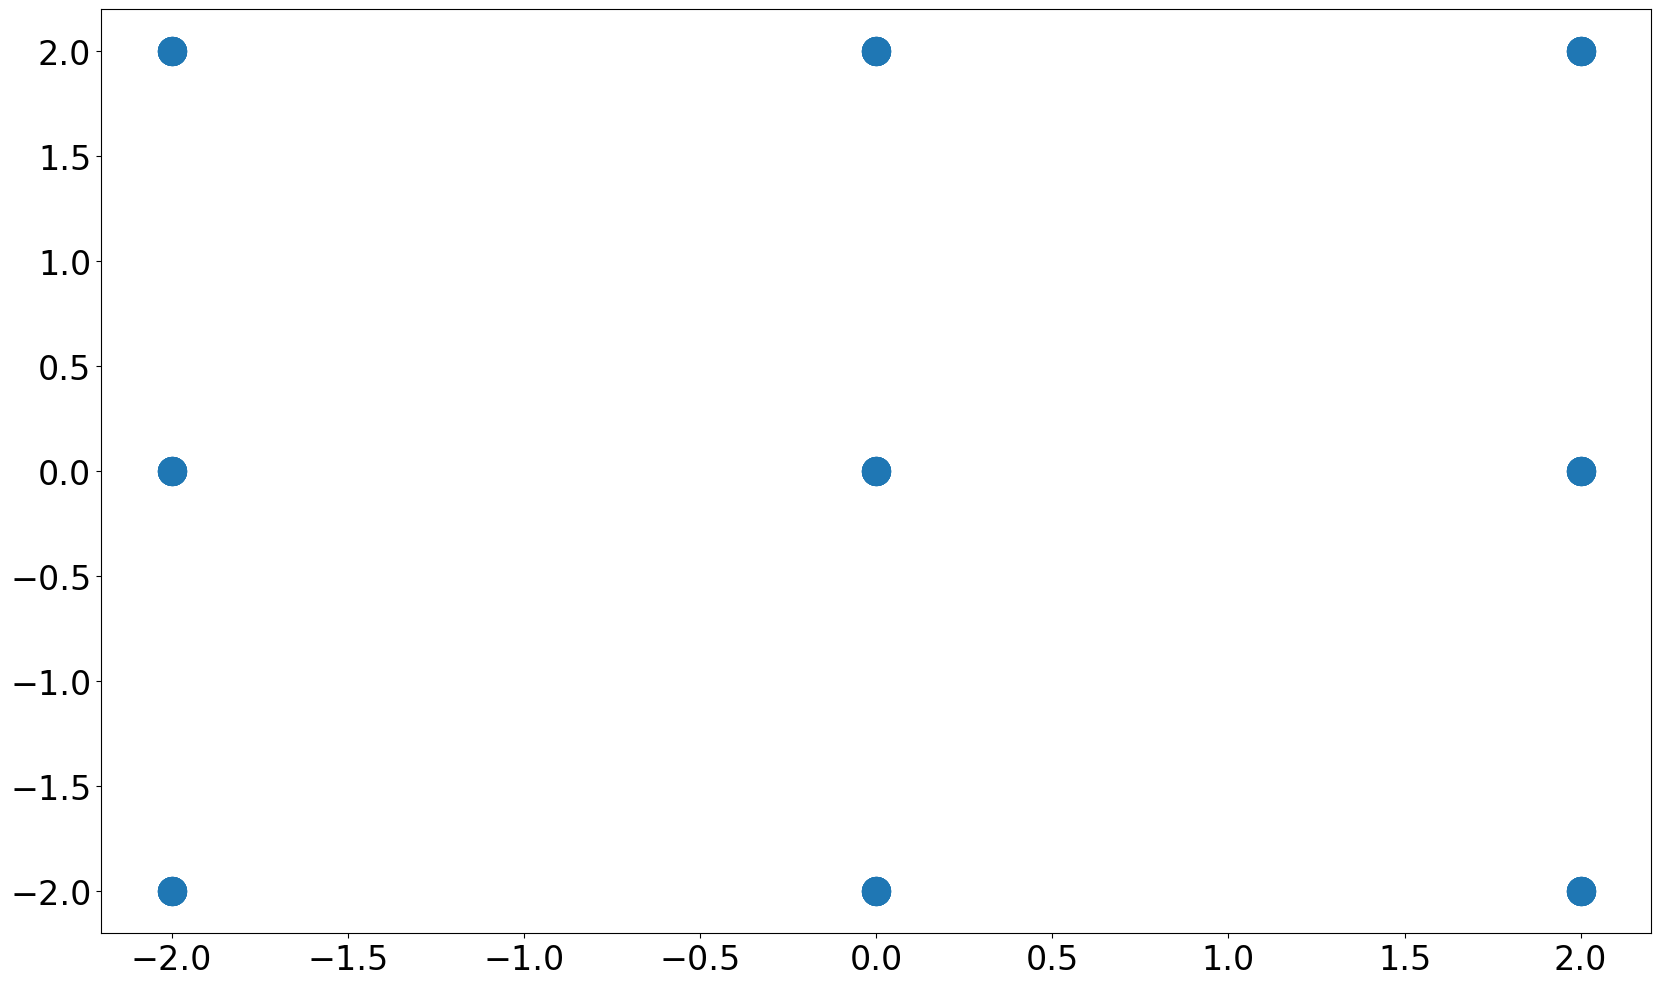

In [100]:
import numpy as np
import torch
from torch.utils.data import Dataset
from itertools import product

num_samples = 81
encode_num = 4
mean = 0
std_dev = 2
seed = 0
jitter_frac = 0.0

rng = np.random.default_rng(seed)
#take the qth root of the number of samples
q = round(num_samples ** (1 / encode_num))

#Validate the sample size to make sure it is an (encode_num)th power
if q ** encode_num != num_samples:
    raise ValueError(
    f"num_samples={num_samples} is not a perfect "
    f"{encode_num}th power")

#Create q evenly spaced points
col = np.linspace(start=mean-std_dev, stop=mean+std_dev, num=q, dtype=np.float32)

#Take cartesian products with self encode_num times
X = np.array(list(product(col, repeat=encode_num)),dtype=np.float32)

grid_spacing = col[1] - col[0]
jitter_radius = jitter_frac * grid_spacing

noise = rng.uniform(
    -jitter_radius,
    jitter_radius,
    size=X.shape,
)

X_jittered = X + noise
fig, ax = plt.subplots(figsize=(20,12))
ax.scatter(X_jittered[:, 0], X_jittered[:, 1,], alpha=0.7,s=400)
#ax.set_xlabel("X1")
#ax.set_ylabel("X2")
ax.tick_params(axis='both', labelsize=24)
plt.savefig("/content/drive/MyDrive/MSRP/Poster_graphs/grid_scatter.png", bbox_inches='tight')

Random data scatter

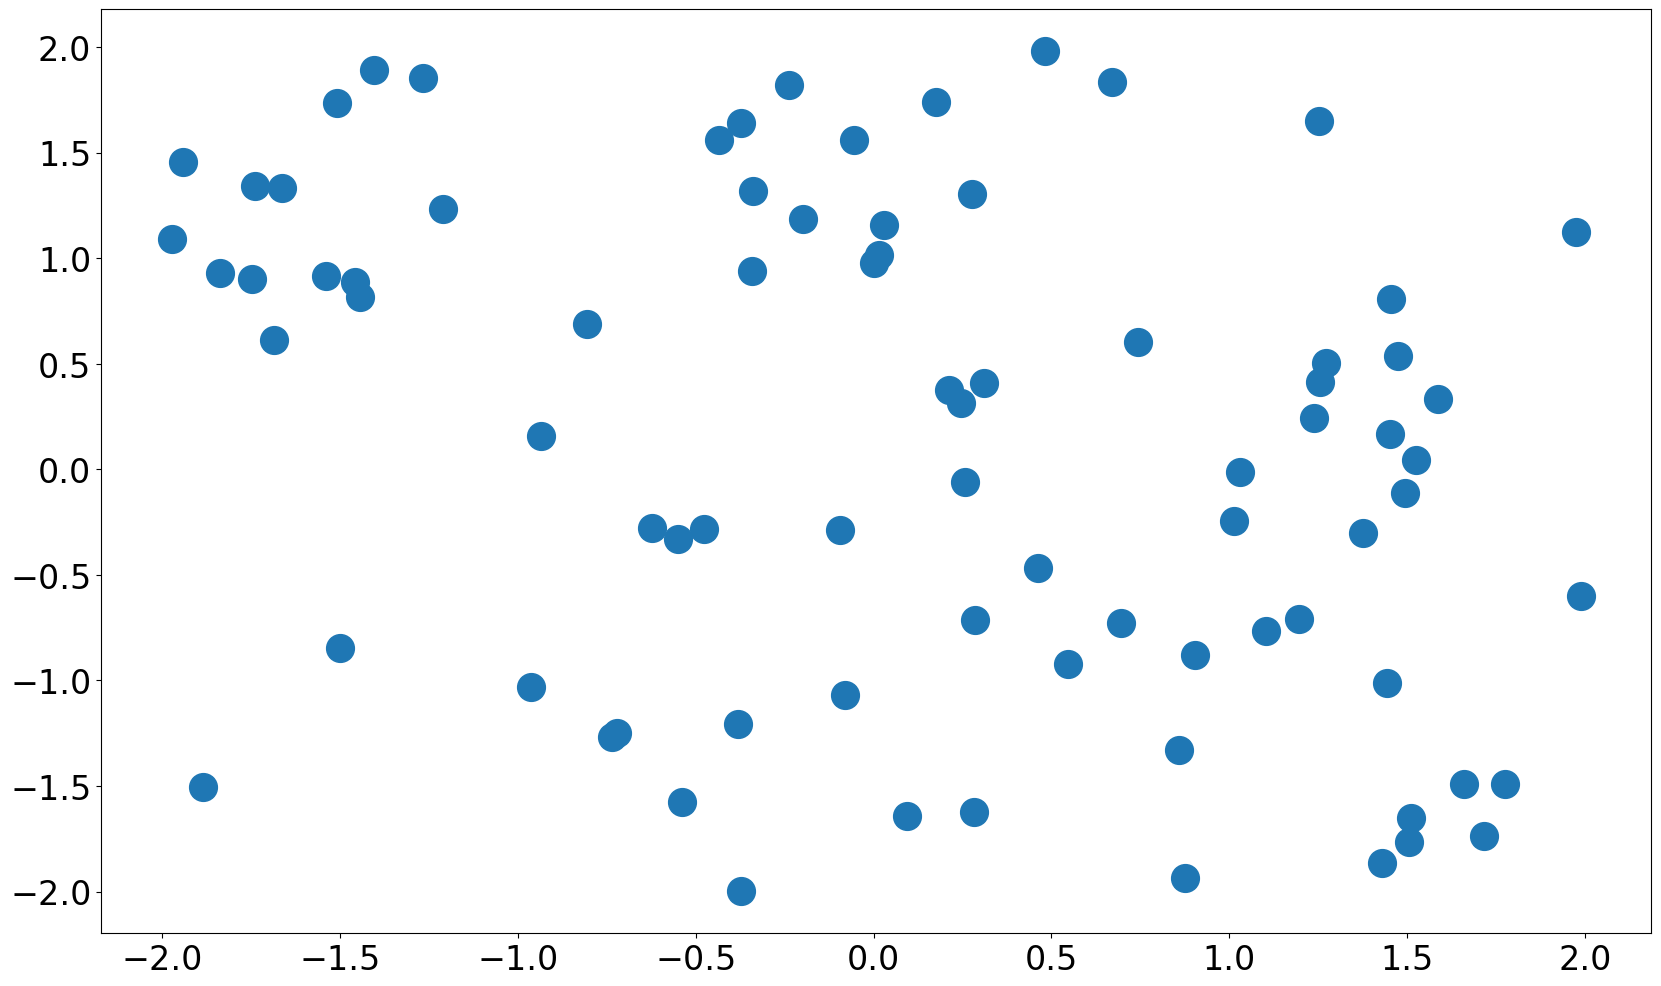

In [101]:
num_samples = 81
encode_num = 4
mean = 0
std_dev = 2
seed = 0


rng = np.random.default_rng(seed)
data = (rng.random((num_samples, encode_num)) - 0.5) * 2 * std_dev + mean

fig, ax = plt.subplots(figsize=(20,12))
ax.scatter(data[:, 0], data[:, 1,], alpha=1,s=400)
#ax.set_xlabel("X1")
#ax.set_ylabel("X2")
ax.tick_params(axis='both', labelsize=24)
plt.savefig("/content/drive/MyDrive/MSRP/Poster_graphs/random_scatter.png", bbox_inches='tight')

Monte Carlo Abs. Corr.

In [104]:
data = np.load("/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-07-26/exp35_one_seed_MC_metrics_w500cand_vs_iid_v_grid/datasets/MC_mean_abs_corr_samples_81_seed_1.npy")

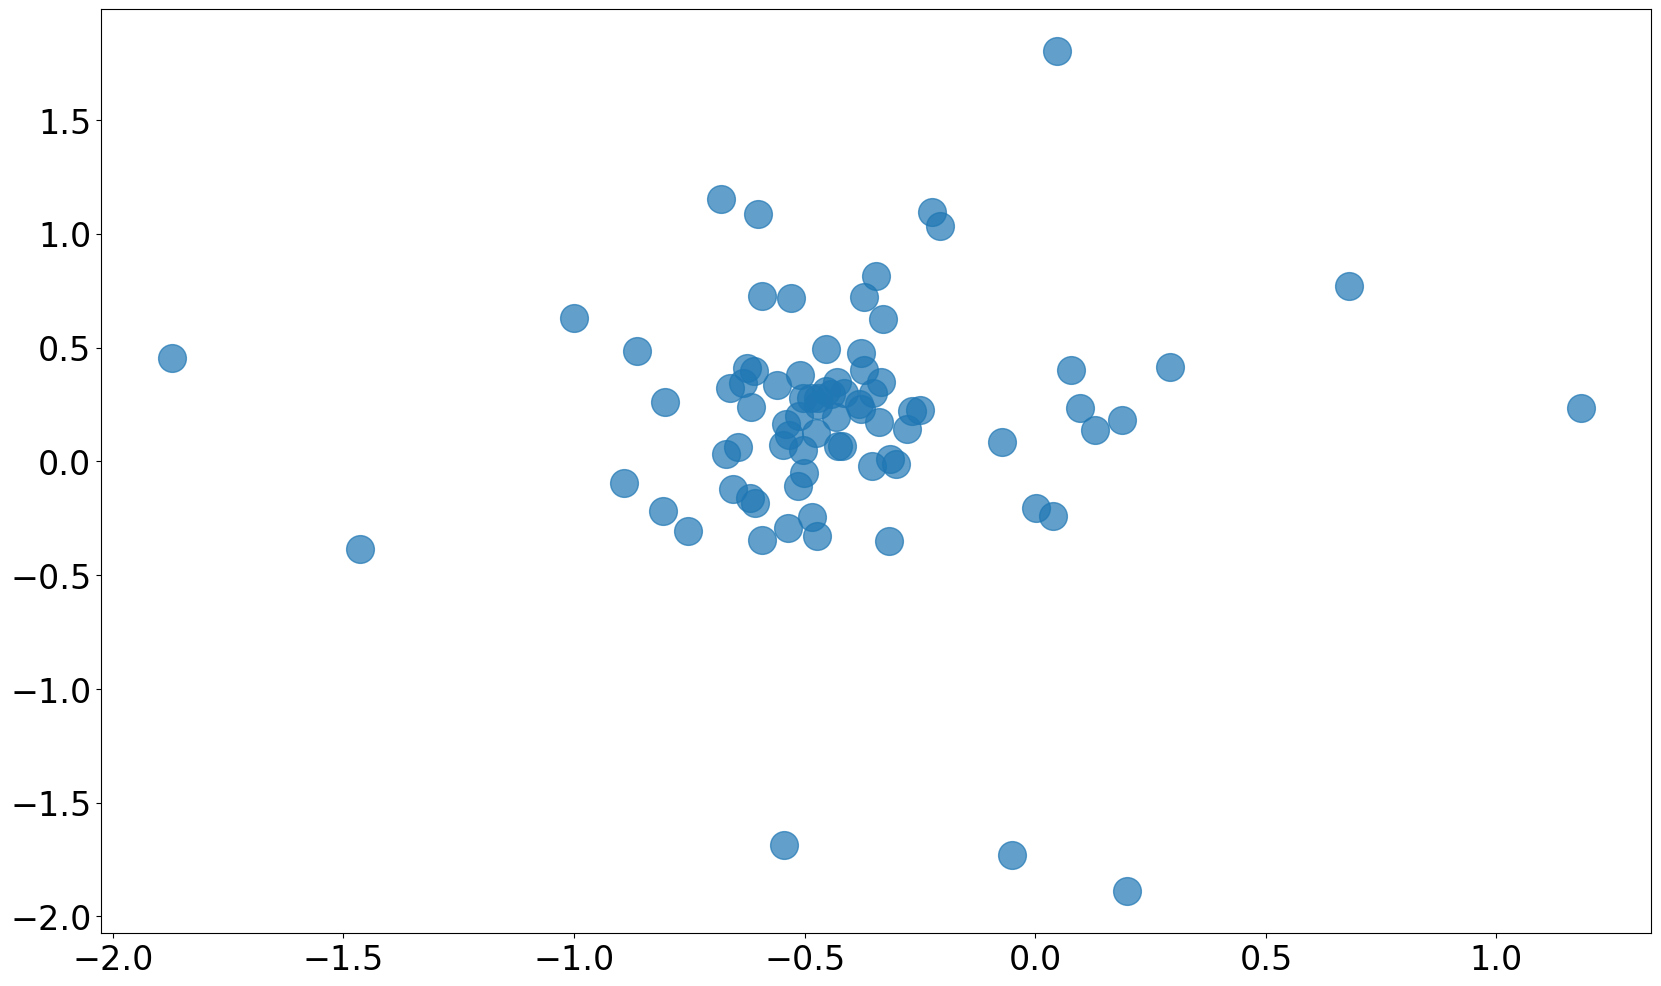

In [106]:
fig, ax = plt.subplots(figsize=(20,12))
ax.scatter(data[:, 0], data[:, 1,], alpha=0.7,s=400)
#ax.set_xlabel("X1")
#ax.set_ylabel("X2")
ax.tick_params(axis='both', labelsize=24)
plt.savefig("/content/drive/MyDrive/MSRP/Poster_graphs/mc_mean_abs_corr_scatter.png", bbox_inches='tight')

Grid + Additions

In [107]:
num_samples = 81
encode_num = 4
mean = 0
std_dev = 2
seed = 0
add_iid = 2

rng = np.random.default_rng(seed)
#take the qth root of the number of samples
q = round(num_samples ** (1 / encode_num))

#Validate the sample size to make sure it is an (encode_num)th power
if q ** encode_num != num_samples:
    raise ValueError(
    f"num_samples={num_samples} is not a perfect "
    f"{encode_num}th power")

#Create q evenly spaced points
col = np.linspace(start=mean-std_dev, stop=mean+std_dev, num=q, dtype=np.float32)

#Take cartesian products with self encode_num times
X = np.array(list(product(col, repeat=encode_num)),dtype=np.float32)

# Generate an array of iid samples
X_iid = (
    rng.random((add_iid, encode_num)) - 0.5
) * 2 * std_dev + mean

data = np.concatenate(
    [X, X_iid],
    axis=0,
).astype(np.float32)

print(f"Random points generated: {X_iid}\n")

print(
        f"Grid points: {len(X)}, "
        f"added iid points: {len(X_iid)}, "
        f"total points: {len(data)}"
    )
data = data[rng.permutation(len(data))]

Random points generated: [[ 0.54784675 -0.92085314 -1.8361059  -1.93388946]
 [ 1.25308096  1.65102231  0.4265431   0.91798624]]

Grid points: 81, added iid points: 2, total points: 83


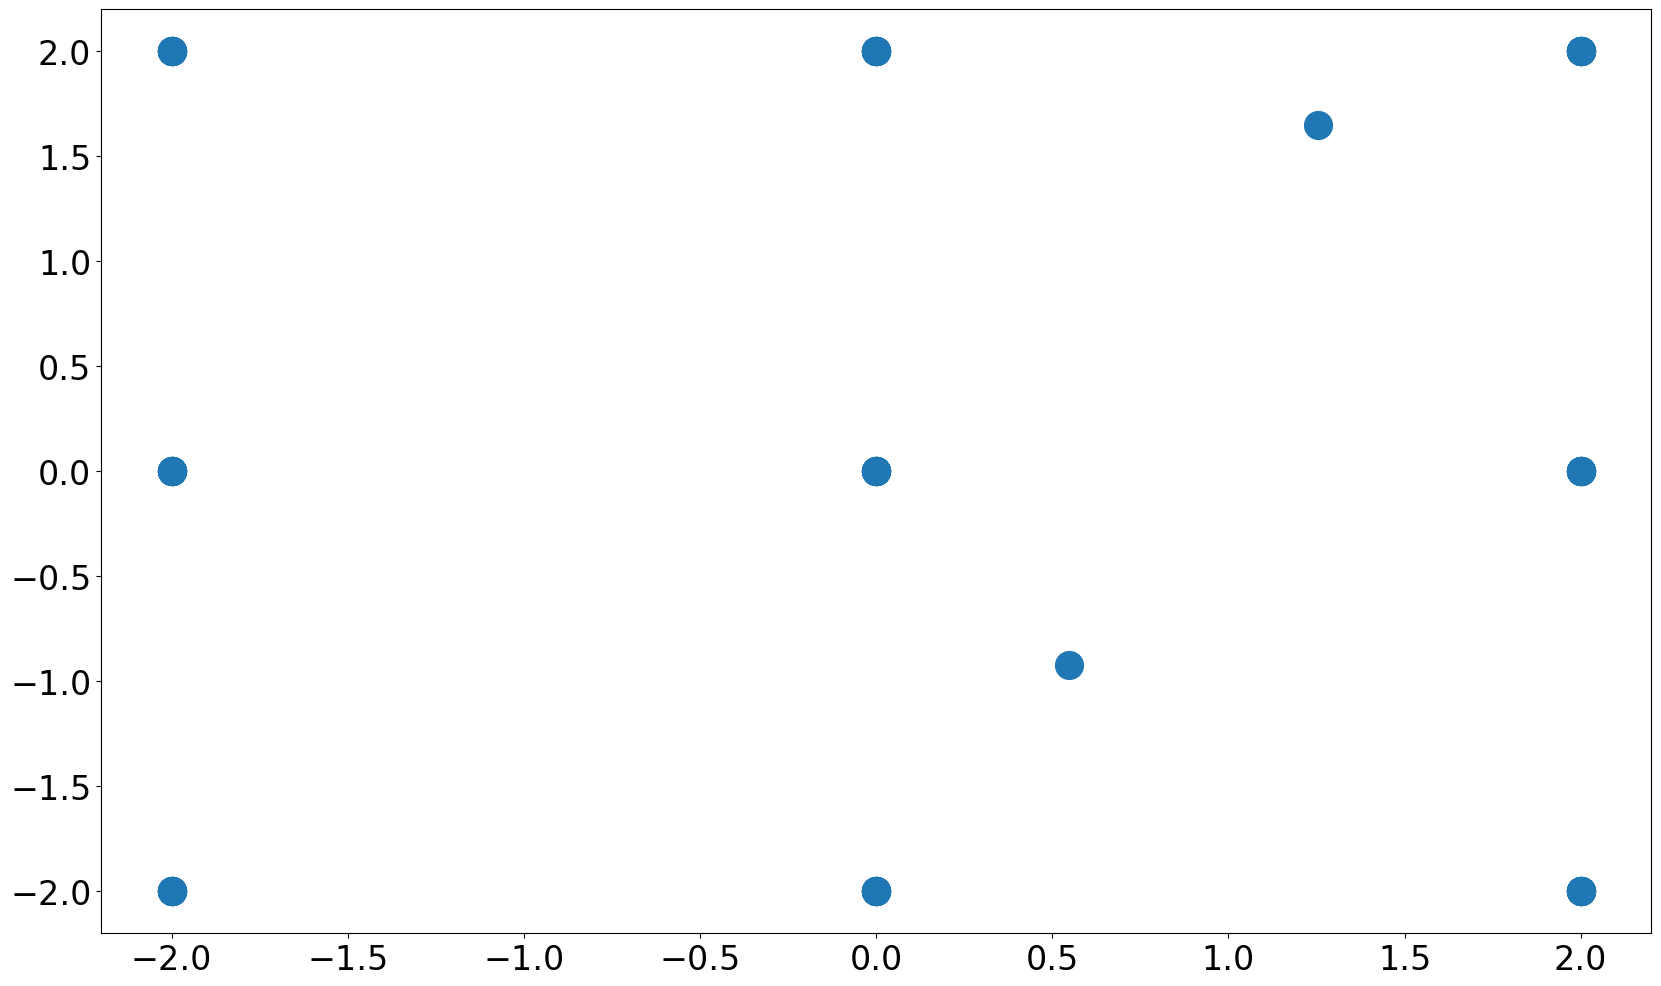

In [108]:
fig, ax = plt.subplots(figsize=(20,12))
ax.scatter(data[:, 0], data[:, 1,], alpha=1,s=400)
#ax.set_xlabel("X1")
#ax.set_ylabel("X2")
ax.tick_params(axis='both', labelsize=24)
plt.savefig("/content/drive/MyDrive/MSRP/Poster_graphs/grid_random_add_scatter.png", bbox_inches='tight')

Evenly sampled

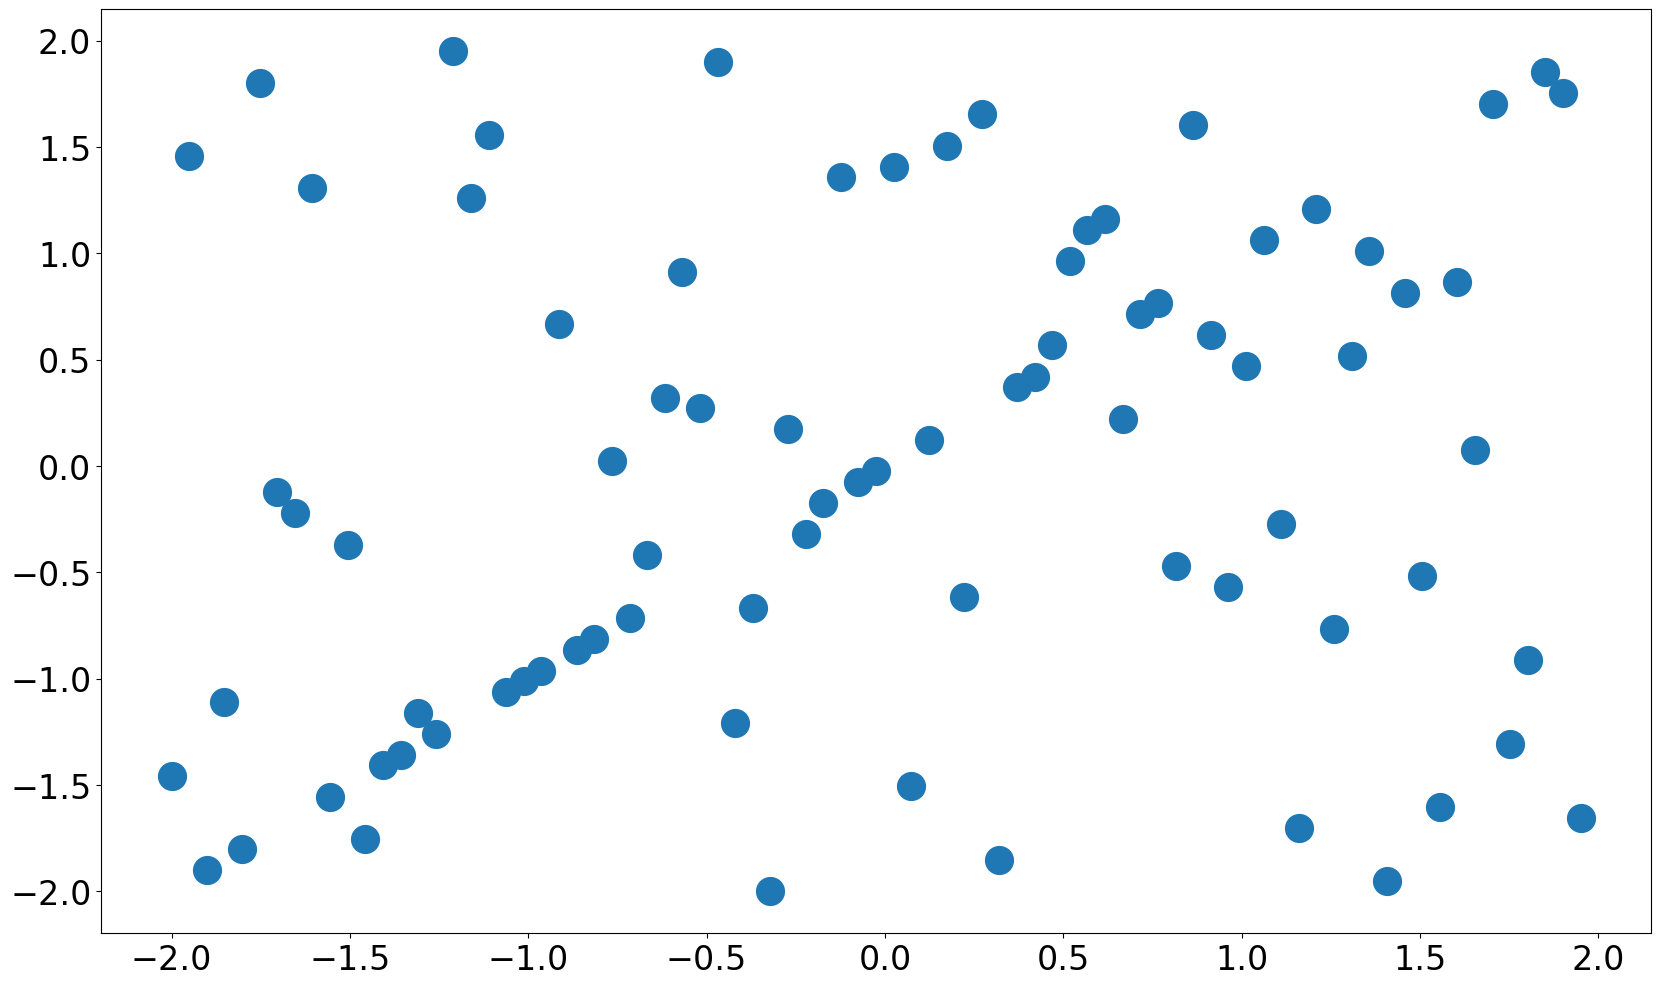

In [109]:
num_samples = 81
encode_num = 4
mean = 0
std_dev = 2
seed = 0
shuffle_frac = 0.7

col = np.linspace(start=mean-std_dev, stop=mean+std_dev, num=num_samples, endpoint=False)
X = np.column_stack([col]*encode_num)

if shuffle_frac > 0:
    rng = np.random.default_rng()
    num_samples, encode_num = X.shape
    k = int(round(shuffle_frac * num_samples))

    for j in range(1, encode_num):
        rows = rng.choice(num_samples, size=k, replace=False)
        shuffled_values = X[rows, j].copy()
        rng.shuffle(shuffled_values)
        X[rows, j] = shuffled_values

data = X

fig, ax = plt.subplots(figsize=(20,12))
ax.scatter(data[:, 0], data[:, 1,], alpha=1,s=400)
#ax.set_xlabel("X1")
#ax.set_ylabel("X2")
ax.tick_params(axis='both', labelsize=24)
plt.savefig("/content/drive/MyDrive/MSRP/Poster_graphs/permuted_line.png", bbox_inches='tight')


Spectrum graphs


In [189]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def plot_mean_spectrum_from_df(
    df,
    folder,
    file_name,
    condition_col=None,
    condition_value=None,
    n_layers=4,
    n_modes=10,
    file_format="png",
    figsize=(8, 6),
    dpi=600,
    show_std=True,
):
    if condition_col is not None:
        condition_df = df.loc[
            df[condition_col] == condition_value
        ].copy()
    else:
        condition_df = df.copy()

    if condition_df.empty:
        raise ValueError("No rows match the requested condition.")

    fig, ax = plt.subplots(figsize=figsize)

    for layer_idx in range(n_layers):
        mode_indices = []
        columns = []

        for mode_idx in range(1, n_modes + 1):
            column = f"eig_layer{layer_idx}_mode{mode_idx}"

            if column in condition_df.columns:
                mode_indices.append(mode_idx)
                columns.append(column)

        if not columns:
            continue

        spectra = condition_df[columns].to_numpy(dtype=float)

        mean_spectrum = np.nanmean(spectra, axis=0)
        std_spectrum = np.nanstd(
            spectra,
            axis=0,
            ddof=1,
        )

        mode_indices = np.asarray(mode_indices)

        color = mpl.colormaps.get_cmap("plasma")(
            layer_idx / n_layers
        )

        ax.plot(
            mode_indices,
            mean_spectrum,
            color=color,
            linewidth=3,
            marker="o",
            markersize=8,
            label=f"Layer {layer_idx}",
        )

        if show_std:
            ax.fill_between(
                mode_indices,
                mean_spectrum - std_spectrum,
                mean_spectrum + std_spectrum,
                color=color,
                alpha=0.06,
                linewidth=0,
            )
            # mask = np.isin(mode_indices, [4, 5])

            # ax.errorbar(
            #     mode_indices[mask],
            #     mean_spectrum[mask],
            #     yerr=std_spectrum[mask],
            #     fmt='none',
            #     ecolor=color,
            #     elinewidth=1,
            #     capsize=3,
            #     alpha=0.7,
            # )

    ax.set_xlabel("Eigenmode index", fontsize=22)
    ax.set_ylabel("Eigenvalue", fontsize=22)

    ax.tick_params(
        axis="both",
        labelsize=18,
        width=1.5,
        length=6,
    )

    ax.legend(
        fontsize=17,
        frameon=True,
        loc="best",
    )

    ax.set_xlim(0, n_modes + 1)
    ax.set_ylim(-0.2, 1.2)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    fig.tight_layout()
    plt.show()

    fig.savefig(
        f"{folder}/{file_name}.{file_format}",
        dpi=dpi,
        bbox_inches="tight",
    )

    plt.close(fig)

In [187]:
df = pd.read_csv("/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-08-05/exp44_MC_MI_81_for_poster/results.csv")

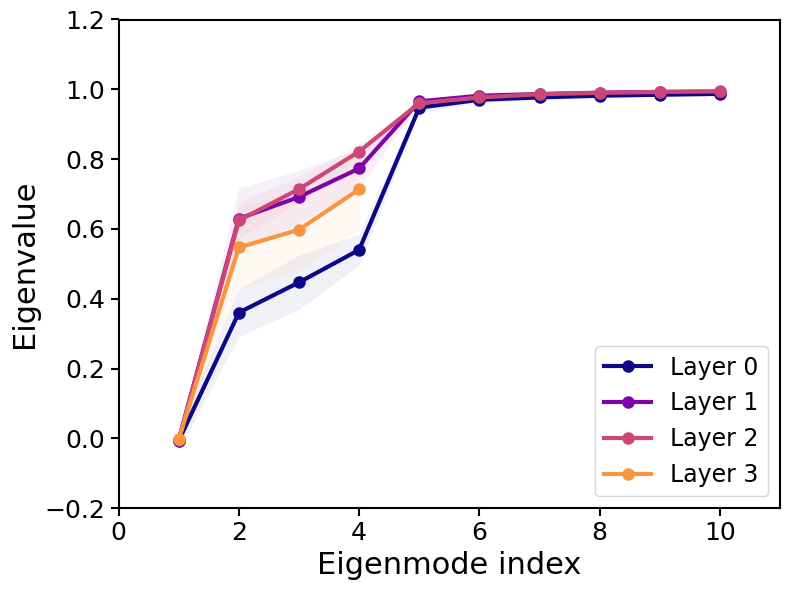

In [190]:
plot_mean_spectrum_from_df(
    df=df,
    condition_col="sampling_mode",
    condition_value="monte_carlo",
    folder="/content/drive/MyDrive/MSRP/Poster_graphs",
    file_name="MC_Mean_MI_mean_spectrum",
    n_layers=4,
    n_modes=10,
    dpi=600,
)

\
\
\

Graph 4th gaps



\
\
\
\

In [ ]:
path = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-26/exp23_super_extensive_jitter_sweep_5_seeds"
results = pd.read_csv(path + "/results.csv")

results["jitter_diameter"] = 4*results["jitter"]

gap_columns = ["4th_gap_layer0", "4th_gap_layer1", "4th_gap_layer2"]

summary = (results
           .groupby("jitter_diameter")[gap_columns]
           .agg(["mean", "max", "min", "std"])
           .reset_index()
           .sort_values("jitter_diameter"))

# summary.to_csv(path + "/summary.csv")

In [168]:
cmap2 = mpl.colormaps.get_cmap("plasma")

layer_colors = {
    0: cmap2(0 / 4),
    1: cmap2(1 / 4),
    2: cmap2(2 / 4),
    3: cmap2(3 / 4),
}

In [ ]:
#layer_name = "4th_gap_layer0"

def plot_jitter_gaps(layer_name, color):
    for seed, seed_df in results.groupby("seed"):
        seed_df = seed_df.sort_values("jitter_diameter")

        plt.plot(
            seed_df["jitter_diameter"],
            seed_df[layer_name],
            color=color,
            alpha=0.15,
            linewidth=1
        )

    # Mean and shaded range
    x = summary["jitter_diameter"].to_numpy()
    mean = summary[layer_name]["mean"].to_numpy()
    lower = summary[layer_name]["min"].to_numpy()
    upper = summary[layer_name]["max"].to_numpy()

    plt.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=0.15
    )

    plt.plot(
        x,
        mean,
        color=color,
        linewidth=2.5,
        label="Mean"
    )

Text(0.5, 1.0, 'Layer 0')

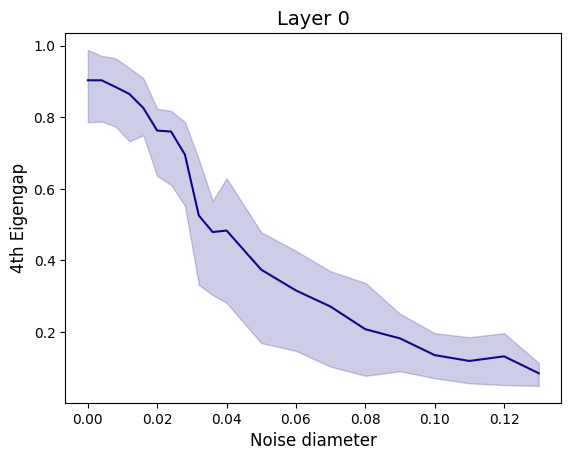

In [ ]:
plt.plot(summary["jitter_diameter"], summary["4th_gap_layer0"]["mean"], color=layer_colors[0])
plt.fill_between(summary["jitter_diameter"], summary["4th_gap_layer0"]["min"], summary["4th_gap_layer0"]["max"], color=layer_colors[0], alpha=0.2)
plt.xlabel("Noise diameter", size=12)
plt.ylabel("4th Eigengap", size=12)
plt.title("Layer 0", size=14)

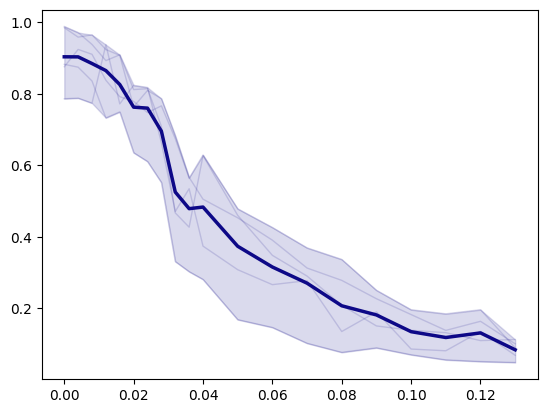

In [ ]:
plot_jitter_gaps("4th_gap_layer0", layer_colors[0])

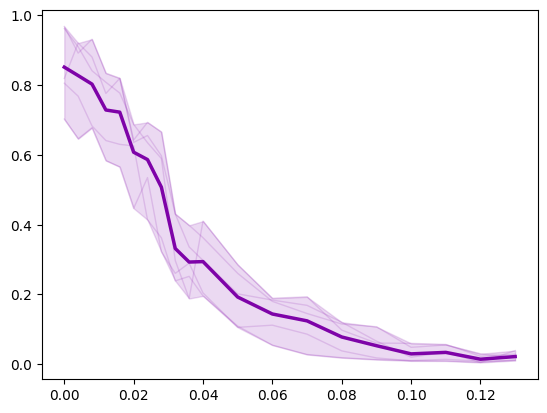

In [ ]:
plot_jitter_gaps("4th_gap_layer1", layer_colors[1])

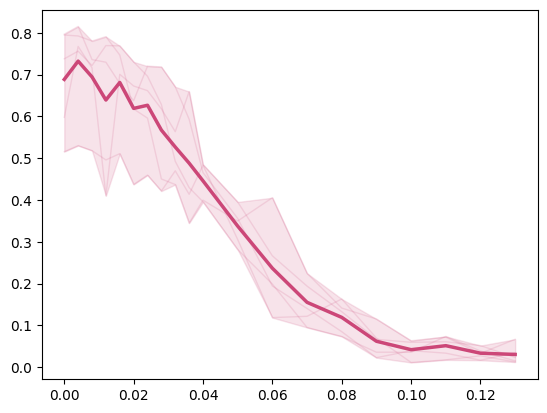

In [ ]:
plot_jitter_gaps("4th_gap_layer2", layer_colors[2])

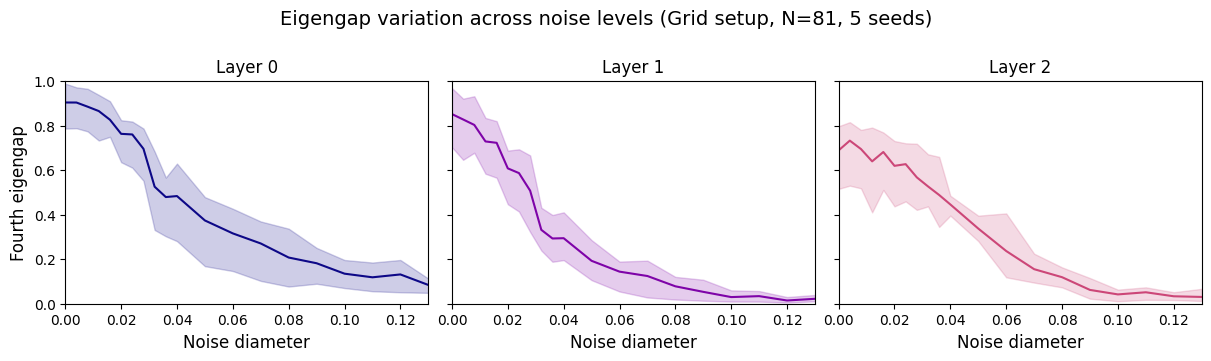

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

x = summary["jitter_diameter"].to_numpy()

for i, (ax, layer) in enumerate(zip(axes, gap_columns)):
    color = cmap2(i / 4)  # matches the original four-layer color convention

    mean = summary[layer]["mean"].to_numpy()
    lower = summary[layer]["min"].to_numpy()
    upper = summary[layer]["max"].to_numpy()

    ax.plot(x, mean, color=color)
    ax.fill_between(
        x,
        lower,
        upper,
        color=color,
        alpha=0.2
    )

    ax.set_title(f"Layer {i}", size = 12)
    ax.set_xlabel("Noise diameter", size = 12)
    ax.set_xlim(0, 0.13)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fourth eigengap", size = 12)

fig.suptitle("Eigengap variation across noise levels (Grid setup, N=81, 5 seeds)\n", size = 14)

# fig.savefig(
#     path + "/eigengap_variation_across_noise.pdf",
#     bbox_inches="tight"
# )

plt.show()

Text(0.5, 0.98, 'Eigengap variation across noise levels (Grid setup, N=81, 5 seeds)\n')

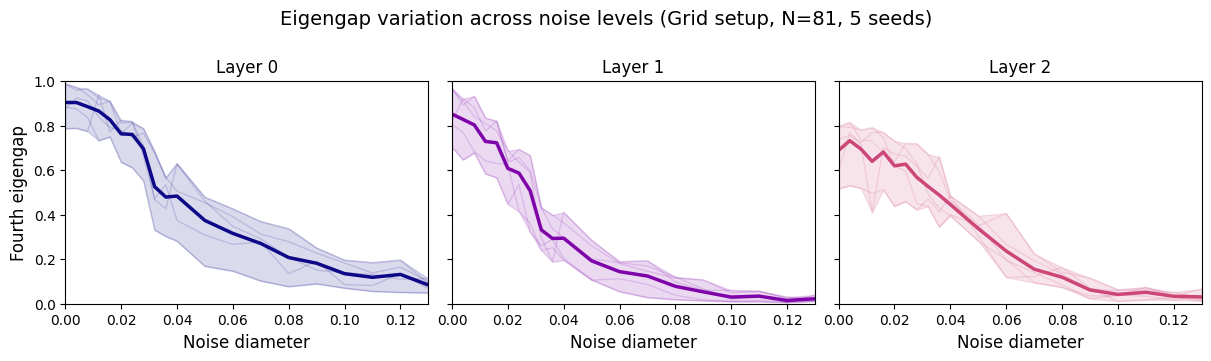

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

x = summary["jitter_diameter"].to_numpy()

for i, (ax, layer) in enumerate(zip(axes, gap_columns)):
    color = layer_colors[i]

    for seed, seed_df in results.groupby("seed"):
        seed_df = seed_df.sort_values("jitter_diameter")

        ax.plot(
            seed_df["jitter_diameter"],
            seed_df[layer],
            color=color,
            alpha=0.15,
            linewidth=1
        )

    ax.fill_between(
        x,
        summary[layer]["min"].to_numpy(),
        summary[layer]["max"].to_numpy(),
        color=color,
        alpha=0.15
    )

    ax.plot(
        x,
        summary[layer]["mean"].to_numpy(),
        color=color,
        linewidth=2.5
    )

    ax.set_title(f"Layer {i}", size = 12)
    ax.set_xlabel("Noise diameter", size = 12)
    ax.set_xlim(0, 0.13)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fourth eigengap", size = 12)
fig.suptitle("Eigengap variation across noise levels (Grid setup, N=81, 5 seeds)\n", size = 14)

# fig.savefig(
#     path + "/eigengap_variation_across_noise_nice.pdf",
#     bbox_inches="tight"
# )

Do Additions vs 4th Gaps

In [166]:
path = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-08-05/exp42_sweep_additions_grid_81_for_poster"
results = pd.read_csv(path + "/results.csv")

gap_columns = ["4th_gap_layer0", "4th_gap_layer1", "4th_gap_layer2"]

summary = (results
           .groupby("add_iid")[gap_columns]
           .agg(["mean", "max", "min", "std"])
           .reset_index()
           .sort_values("add_iid"))

summary.to_csv(path + "/summary.csv")

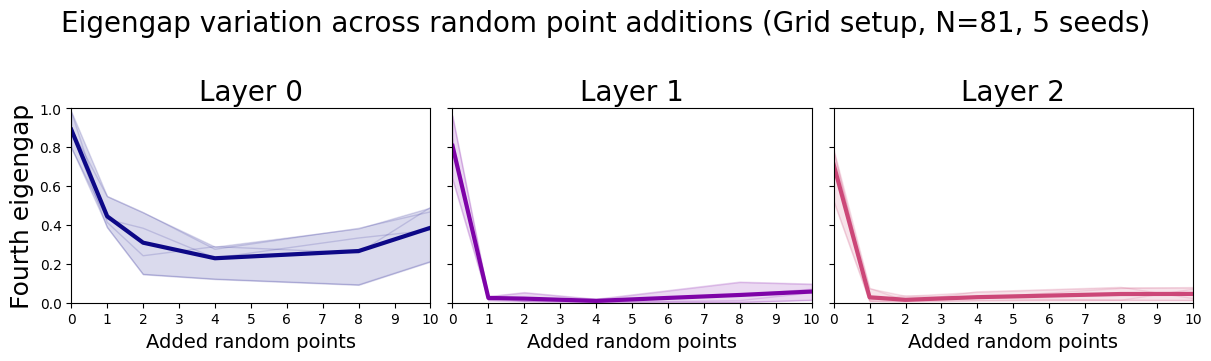

In [178]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 3.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

x = summary["add_iid"].to_numpy()

for i, (ax, layer) in enumerate(zip(axes, gap_columns)):
    color = layer_colors[i]

    for seed, seed_df in results.groupby("seed"):
        seed_df = seed_df.sort_values("add_iid")

        ax.plot(
            seed_df["add_iid"],
            seed_df[layer],
            color=color,
            alpha=0.15,
            linewidth=1
        )

    ax.fill_between(
        x,
        summary[layer]["min"].to_numpy(),
        summary[layer]["max"].to_numpy(),
        color=color,
        alpha=0.15
    )

    ax.plot(
        x,
        summary[layer]["mean"].to_numpy(),
        color=color,
        linewidth=3
    )

    ax.set_title(f"Layer {i}", size = 20)
    ax.set_xlabel("Added random points", size = 14)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1)

ax.set_xticks(np.arange(0,11,1))
axes[0].set_ylabel("Fourth eigengap", size = 18)
fig.suptitle("Eigengap variation across random point additions (Grid setup, N=81, 5 seeds)\n", size = 20)

fig.savefig(
    path + "/eigengap_variation_across_additions.pdf",
    bbox_inches="tight"
)

\
\
\
\
Graph MI vs 4th gaps
\
\
\


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-26/exp24_MI_tests1/results.csv")

In [ ]:
df_sorted = df.sort_values(by="mean_mi_bw_0p02")

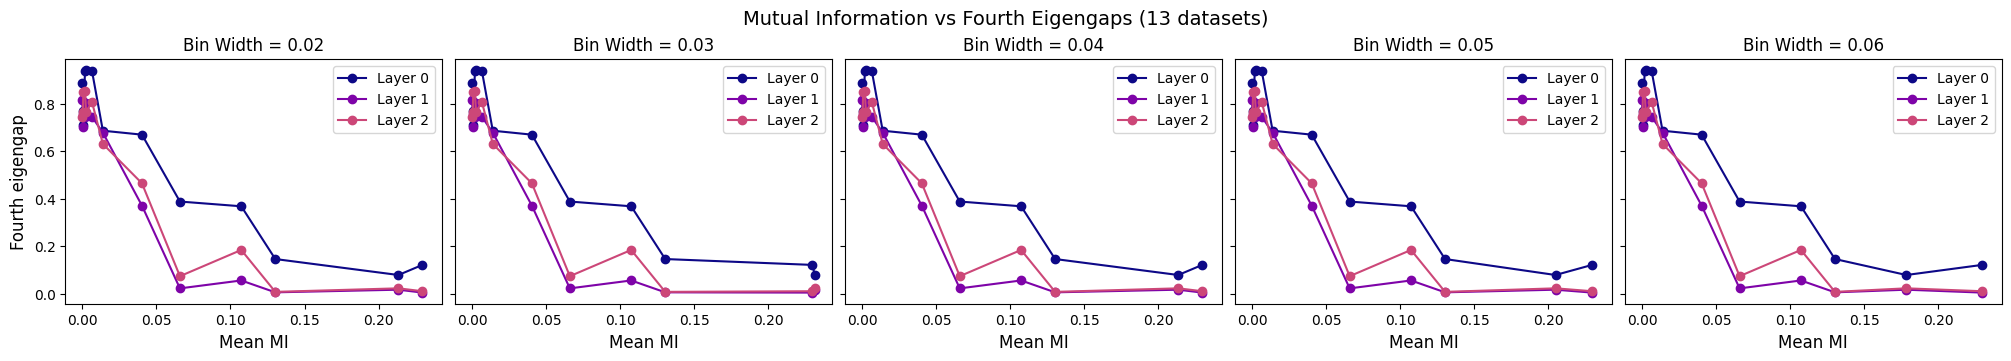

In [ ]:
bin_widths = ["02", "03", "04", "05", "06"]

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 3.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)


for i, (ax, width) in enumerate(zip(axes, bin_widths)):

    bin_key = f"mean_mi_bw_0p{width}"
    df_sorted = df.sort_values(by=bin_key)
    df_sorted = df_sorted.drop(0)

    ax.plot(df_sorted[bin_key], df_sorted["4th_gap_layer0"], marker="o", color=layer_colors[0], label="Layer 0")
    ax.plot(df_sorted[bin_key], df_sorted["4th_gap_layer1"], marker="o", color=layer_colors[1], label="Layer 1")
    ax.plot(df_sorted[bin_key], df_sorted["4th_gap_layer2"], marker="o", color=layer_colors[2], label="Layer 2")

    ax.set_title(f"Bin Width = 0.{width}")
    ax.set_xlabel("Mean MI", size = 12)
    ax.legend()
    # ax.set_xlim(0, 0.13)
    # ax.set_ylim(0, 1)

axes[0].set_ylabel("Fourth eigengap", size = 12)
fig.suptitle("Mutual Information vs Fourth Eigengaps (13 datasets)", size = 14)

MI_path = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-26/exp24_MI_tests1"
fig.savefig(
    MI_path + "/MI_vs_4th_Eigengaps.pdf",
    bbox_inches="tight"
)

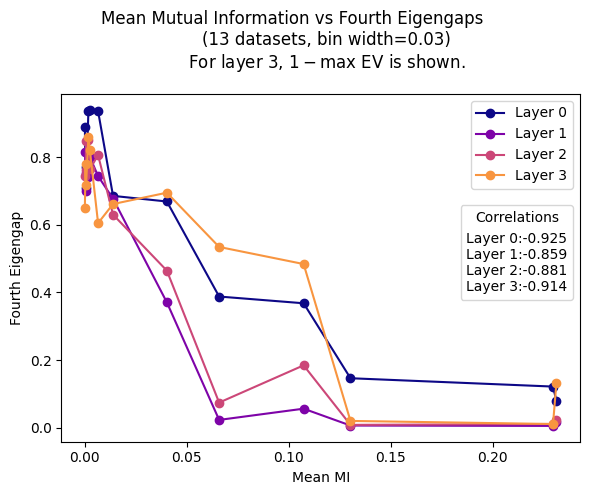

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

df_sorted = df.sort_values(by="mean_mi_bw_0p03")
df_sorted = df_sorted.drop(0)

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Mean MI")
ax.set_ylabel("Fourth Eigengap")

layer0_line, = ax.plot(df_sorted["mean_mi_bw_0p03"], df_sorted["4th_gap_layer0"], marker="o", color=layer_colors[0], label="Layer 0")
layer1_line, = ax.plot(df_sorted["mean_mi_bw_0p03"], df_sorted["4th_gap_layer1"], marker="o", color=layer_colors[1], label="Layer 1")
layer2_line, = ax.plot(df_sorted["mean_mi_bw_0p03"], df_sorted["4th_gap_layer2"], marker="o", color=layer_colors[2], label="Layer 2")
layer3_line, = ax.plot(df_sorted["mean_mi_bw_0p03"], 1-df_sorted["max_EV_layer3"], marker="o", color=layer_colors[3], label="Layer 3")

first_legend = ax.legend(handles=[layer0_line, layer1_line, layer2_line, layer3_line],
                         loc='upper right',
                        )
ax.add_artist(first_legend)

corr_coefficient0, p_value0 = pearsonr(df_sorted["mean_mi_bw_0p03"], df_sorted["4th_gap_layer0"])
corr_coefficient1, p_value1 = pearsonr(df_sorted["mean_mi_bw_0p03"], df_sorted["4th_gap_layer1"])
corr_coefficient2, p_value2 = pearsonr(df_sorted["mean_mi_bw_0p03"], df_sorted["4th_gap_layer2"])
corr_coefficient3, p_value3 = pearsonr(df_sorted["mean_mi_bw_0p03"], 1-df_sorted["max_EV_layer3"])

text_patch_1 = mpatches.Patch(color="none", label=f"Layer 0:{corr_coefficient0:.3f}\nLayer 1:{corr_coefficient1:.3f}\nLayer 2:{corr_coefficient2:.3f}\nLayer 3:{corr_coefficient3:.3f}")
ax.legend(handles=[text_patch_1],
          #loc='center right',
          bbox_to_anchor=(1.0, 0.7),
          handlelength=0,
          handletextpad=0,
          title="Correlations"
)

fig.suptitle(r'''Mean Mutual Information vs Fourth Eigengaps
            (13 datasets, bin width=0.03)
            For layer 3, $1 - $max EV is shown.''')
plt.tight_layout()

plt.savefig(MI_path + "/MI_vs_4th_Eigengaps_bin0p03.pdf", bbox_inches="tight")

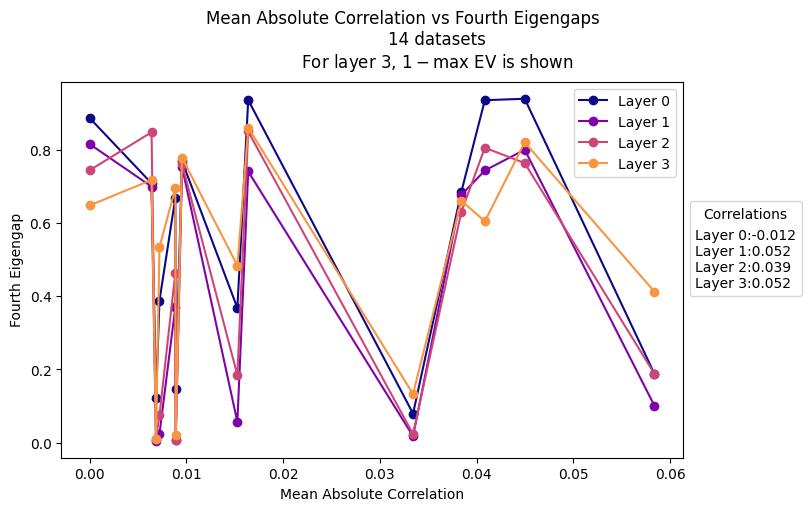

In [ ]:
df_sorted = df.sort_values(by="mean_abs_corr")

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

ax.set_xlabel("Mean Absolute Correlation")
ax.set_ylabel("Fourth Eigengap")

layer0_line, = ax.plot(df_sorted["mean_abs_corr"], df_sorted["4th_gap_layer0"], marker="o", color=layer_colors[0], label="Layer 0")
layer1_line, = ax.plot(df_sorted["mean_abs_corr"], df_sorted["4th_gap_layer1"], marker="o", color=layer_colors[1], label="Layer 1")
layer2_line, = ax.plot(df_sorted["mean_abs_corr"], df_sorted["4th_gap_layer2"], marker="o", color=layer_colors[2], label="Layer 2")
layer3_line, = ax.plot(df_sorted["mean_abs_corr"], 1-df_sorted["max_EV_layer3"], marker="o", color=layer_colors[3], label="Layer 3")

first_legend = ax.legend(handles=[layer0_line, layer1_line, layer2_line, layer3_line],
                         loc='upper right',
                        )
ax.add_artist(first_legend)

corr_coefficient0, p_value0 = pearsonr(df_sorted["mean_abs_corr"], df_sorted["4th_gap_layer0"])
corr_coefficient1, p_value1 = pearsonr(df_sorted["mean_abs_corr"], df_sorted["4th_gap_layer1"])
corr_coefficient2, p_value2 = pearsonr(df_sorted["mean_abs_corr"], df_sorted["4th_gap_layer2"])
corr_coefficient3, p_value3 = pearsonr(df_sorted["mean_abs_corr"], 1-df_sorted["max_EV_layer3"])

text_patch_1 = mpatches.Patch(color="none", label=f"Layer 0:{corr_coefficient0:.3f}\nLayer 1:{corr_coefficient1:.3f}\nLayer 2:{corr_coefficient2:.3f}\nLayer 3:{corr_coefficient3:.3f}")
ax.legend(handles=[text_patch_1],
          #loc='center right',
          bbox_to_anchor=(1.0, 0.7),
          handlelength=0,
          handletextpad=0,
          title="Correlations"
)

fig.suptitle(r'''Mean Absolute Correlation vs Fourth Eigengaps
            14 datasets
            For layer 3, $1 - $max EV is shown''')
#plt.tight_layout()

plt.savefig(MI_path + "/AbsCorr_vs_4th_Eigengaps.pdf", bbox_inches="tight")

\
\
\
Plot Histograms
\
\
\


In [ ]:
def binned_mi_summary(X, bin_edges):
    n_features = X.shape[1]

    binned = np.column_stack([
        np.digitize(X[:, j], bin_edges[1:-1])
        for j in range(n_features)
    ])

    mi_matrix = np.zeros((n_features, n_features))

    for i in range(n_features):
        for j in range(n_features):
            mi = mutual_info_score(binned[:, i], binned[:, j])
            mi_matrix[i, j] = mi

    unique_offdiag = mi_matrix[np.triu_indices(n_features, k=1)]
    #print(mi_matrix)

    return {
        "matrix": mi_matrix,
        "mean": float(np.mean(unique_offdiag)),
        "max": float(np.max(unique_offdiag)),
    }

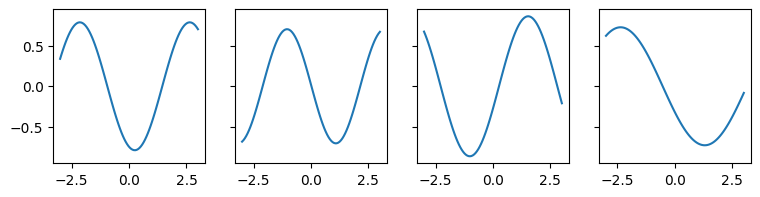

In [ ]:
seed = 145
np.random.seed(seed)


# folder = f'results_{RUN_TYPE}'
# os.makedirs(folder, exist_ok = True)

amps = 0.7 + 0.3 * np.random.rand(encode_num) # * ((np.random.rand(encode_num) > 0) - 0.5)
fres = 0.4 + 1.4 * np.random.rand(encode_num) # 0.4, 0.4 for N8 and N16
phis = 2 * np.pi * np.random.rand(encode_num)
def morph(x):
	return amps * np.sin(fres * x + phis)

# plot to-be-learned functions
fig, axes = plt.subplots(1, encode_num, figsize = (9, 2), sharex = True, sharey = True)
xx = np.linspace(-3, 3, 100)
yy = np.array([morph([x] * encode_num) for x in xx])
for i in range(encode_num):
	axes[i].plot(xx, yy[:, i])

Random Data Histogram

In [ ]:
name = ["iid"]
sampling_mode = ["random_data"]
shuffle_frac = [None]
jitter_frac = [None]
iid_frac = [None]
num_grids = [None]
num_removed = [None]
add_iid = [None]
seed=0
n = 81

dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            sampling_mode=sampling_mode[0],
            shuffle_frac=shuffle_frac[0],
            seed=0,
            jitter_frac=jitter_frac[0],
            iid_frac = iid_frac[0],
            num_grids=num_grids[0],
            num_removed=num_removed[0],
            add_iid=add_iid[0],
        )

X, _ = dataset.get_all_data()
X_np = X.numpy()

In [ ]:
saved = np.load(MI_path + f"/mi_matrices/{name[0]}_samples_{n}_seed_{seed}_mi.npz")
bin_edges = saved["edges_bw_0p06"]

counts, x_edges, y_edges = np.histogram2d(
    X_np[:, 0],
    X_np[:, 1],
    bins=[bin_edges, bin_edges],
)

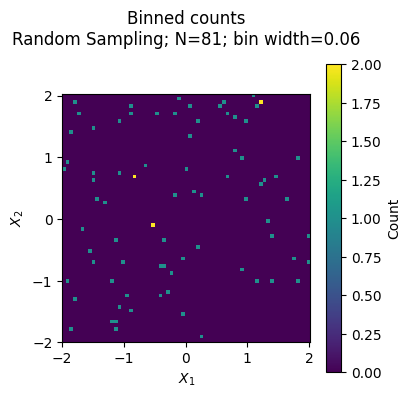

In [ ]:
plt.figure(figsize=(4, 4))

plt.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

plt.xlabel(r"$X_1$")
plt.ylabel(r"$X_2$")
plt.colorbar(label="Count")
plt.title("Binned counts\nRandom Sampling; N=81; bin width=0.06\n \n")
plt.show()

In [ ]:
recomputed = binned_mi_summary(
    X_np,
    bin_edges,
)["matrix"]

In [ ]:
(recomputed)

array([[3.80382315, 3.10653468, 3.09758896, 3.1489332 ],
       [3.10653468, 3.64581645, 2.93958227, 3.00804125],
       [3.09758896, 2.93958227, 3.68821497, 3.05043977],
       [3.1489332 , 3.00804125, 3.05043977, 3.73955921]])

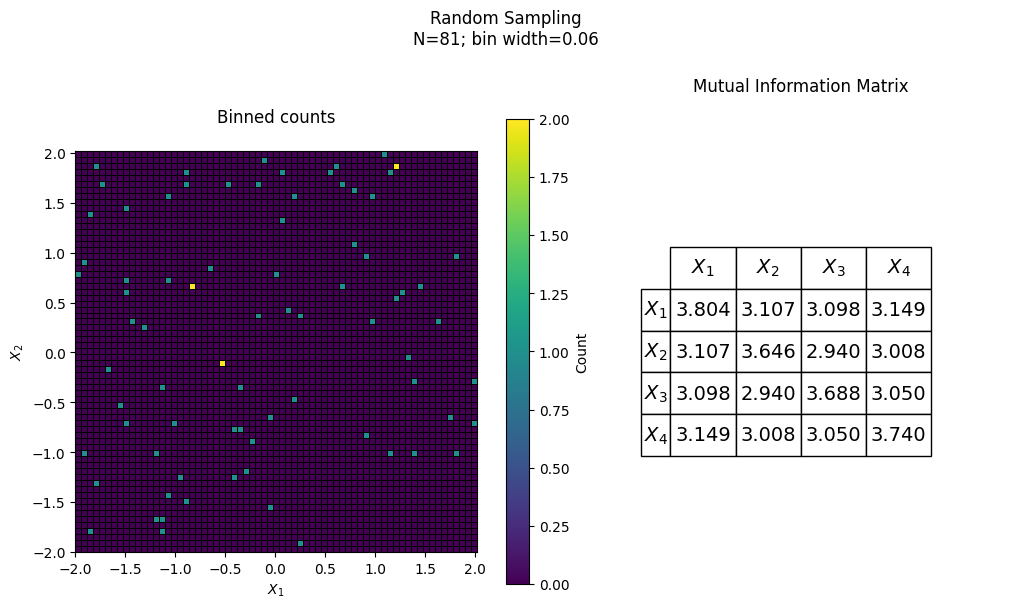

In [ ]:
# Set up a side-by-side Matplotlib layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

# --- Left Subplot: The Graph ---
im = ax1.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Count')
ax1.set_title("Binned counts", pad=20)
ax1.pcolormesh(x_edges, y_edges, counts.T, edgecolors="black", linewidth=0.5)

# --- Right Subplot: The Matrix ---
# Hide the axes lines, ticks, and labels since we only want to show text
ax2.axis("off")

# Render the LaTeX matrix string directly in the center of the subplot
table = ax2.table(
    cellText=[[f"{value:.3f}" for value in row] for row in recomputed],
    rowLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    colLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    cellLoc="center",
    loc="center",
)
table.scale(0.65, 2.5)
table.auto_set_font_size(False)
table.set_fontsize(14)
ax2.set_title("Mutual Information Matrix", pad=20)
fig.suptitle("Random Sampling\nN=81; bin width=0.06\n")
# Adjust layout spacing and show
plt.savefig(MI_path + "/histogram_and_mi_matrix_iid_0p06.pdf", bbox_inches="tight")

In [ ]:
stored = saved["matrix_bw_0p06"]
stored
# print(np.allclose(recomputed, stored))
# print(np.max(np.abs(recomputed - stored)))

array([[3.78444359, 3.17024298, 3.15312824, 3.00975042],
       [3.17024298, 3.7631338 , 3.11470371, 2.98844064],
       [3.15312824, 3.11470371, 3.74601906, 2.97132589],
       [3.00975042, 2.98844064, 2.97132589, 3.61975599]])

\
\
Perfect Grid Histogram
\
\

In [ ]:
name = ["perfect_grid"]
sampling_mode = ["grid"]
shuffle_frac = [None]
jitter_frac = [0.0]
iid_frac = [None]
num_grids = [None]
num_removed = [None]
add_iid = [None]
seed=0
n = 81

dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            sampling_mode=sampling_mode[0],
            shuffle_frac=shuffle_frac[0],
            seed=seed,
            jitter_frac=jitter_frac[0],
            iid_frac = iid_frac[0],
            num_grids=num_grids[0],
            num_removed=num_removed[0],
            add_iid=add_iid[0],
        )

X, _ = dataset.get_all_data()
X_np = X.numpy()

saved = np.load(MI_path + f"/mi_matrices/{name[0]}_samples_{n}_seed_{seed}_mi.npz")
bin_edges = saved["edges_bw_0p06"]

counts, x_edges, y_edges = np.histogram2d(
    X_np[:, 0],
    X_np[:, 1],
    bins=[bin_edges, bin_edges],
)

In [ ]:
recomputed = binned_mi_summary(
    X_np,
    bin_edges,
)["matrix"]

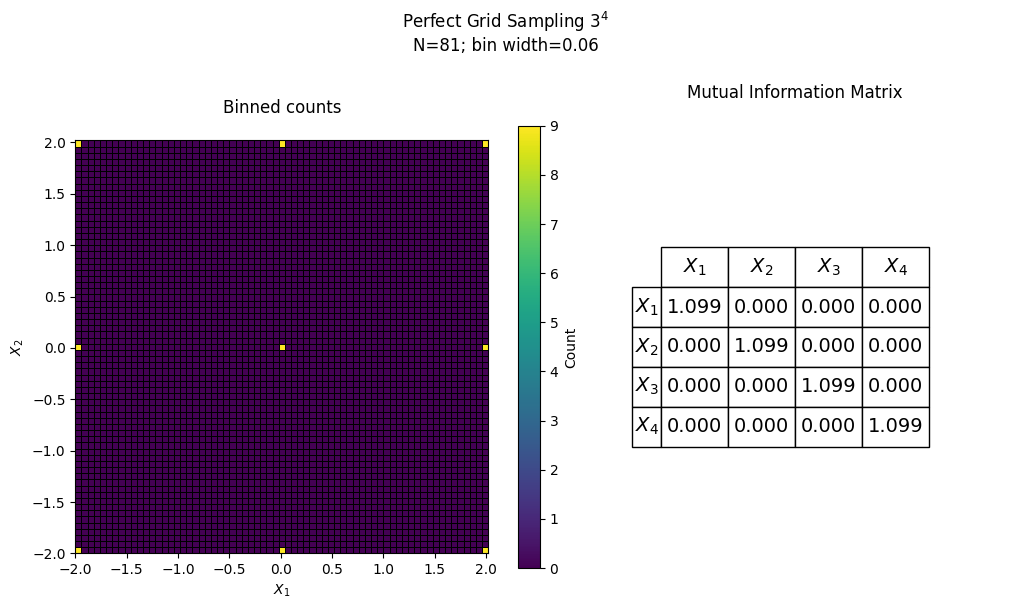

In [ ]:
# Set up a side-by-side Matplotlib layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

# --- Left Subplot: The Graph ---
im = ax1.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Count')
ax1.set_title("Binned counts", pad=20)
ax1.pcolormesh(x_edges, y_edges, counts.T, edgecolors="black", linewidth=0.5)
# --- Right Subplot: The Matrix ---
# Hide the axes lines, ticks, and labels since we only want to show text
ax2.axis("off")

# Render the LaTeX matrix string directly in the center of the subplot
table = ax2.table(
    cellText=[[f"{value:.3f}" for value in row] for row in recomputed],
    rowLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    colLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    cellLoc="center",
    loc="center",
)
table.scale(0.65, 2.5)
table.auto_set_font_size(False)
table.set_fontsize(14)
ax2.set_title("Mutual Information Matrix", pad=20)
fig.suptitle("Perfect Grid Sampling" + r" $3^4$ " +"\nN=81; bin width=0.06\n")

plt.savefig(MI_path + "/histogram_and_mi_matrix_perfect_grid_0p06.pdf", bbox_inches="tight")

Grid w/27 removals Histogram

In [ ]:
name = ["perfect_delete27"]
sampling_mode = ["grid_partial"]
shuffle_frac = [None]
jitter_frac = [None]
iid_frac = [0.0]
num_grids = [None]
num_removed = [27]
add_iid = [None]
seed=0
n = 81

dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            sampling_mode=sampling_mode[0],
            shuffle_frac=shuffle_frac[0],
            seed=seed,
            jitter_frac=jitter_frac[0],
            iid_frac = iid_frac[0],
            num_grids=num_grids[0],
            num_removed=num_removed[0],
            add_iid=add_iid[0],
        )

X, _ = dataset.get_all_data()
X_np = X.numpy()

saved = np.load(MI_path + f"/mi_matrices/{name[0]}_samples_{n}_seed_{seed}_mi.npz")
bin_edges = saved["edges_bw_0p06"]

counts, x_edges, y_edges = np.histogram2d(
    X_np[:, 0],
    X_np[:, 1],
    bins=[bin_edges, bin_edges],
)

total after deletion: 54 points


In [ ]:
recomputed = binned_mi_summary(
    X_np,
    bin_edges,
)["matrix"]

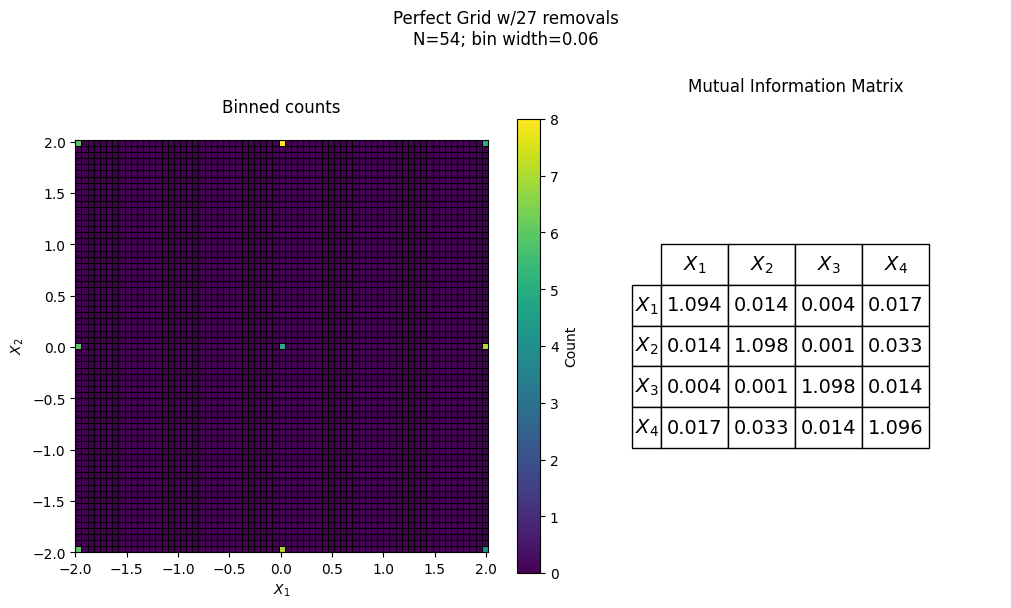

In [ ]:
# Set up a side-by-side Matplotlib layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

# --- Left Subplot: The Graph ---
im = ax1.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Count')
ax1.set_title("Binned counts", pad=20)
ax1.pcolormesh(x_edges, y_edges, counts.T, edgecolors="black", linewidth=0.5)
# --- Right Subplot: The Matrix ---
# Hide the axes lines, ticks, and labels since we only want to show text
ax2.axis("off")

# Render the LaTeX matrix string directly in the center of the subplot
table = ax2.table(
    cellText=[[f"{value:.3f}" for value in row] for row in recomputed],
    rowLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    colLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    cellLoc="center",
    loc="center",
)
table.scale(0.65, 2.5)
table.auto_set_font_size(False)
table.set_fontsize(14)
ax2.set_title("Mutual Information Matrix", pad=20)
fig.suptitle("Perfect Grid w/27 removals\nN=54; bin width=0.06\n")

plt.savefig(MI_path + "/histogram_and_mi_matrix_grid_27removals_0p06.pdf", bbox_inches="tight")

\
\
\
Grid w/2 added random points
\
\
\

In [ ]:
name = ["grid_and_0025_iid"]
sampling_mode = ["grid_partial"]
shuffle_frac = [None]
jitter_frac = [None]
iid_frac = [0.025]
num_grids = [None]
num_removed = [0]
add_iid = [None]
seed=0
n = 81

dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            sampling_mode=sampling_mode[0],
            shuffle_frac=shuffle_frac[0],
            seed=seed,
            jitter_frac=jitter_frac[0],
            iid_frac = iid_frac[0],
            num_grids=num_grids[0],
            num_removed=num_removed[0],
            add_iid=add_iid[0],
        )

X, _ = dataset.get_all_data()
X_np = X.numpy()

saved = np.load(MI_path + f"/mi_matrices/{name[0]}_samples_{n}_seed_{seed}_mi.npz")
bin_edges = saved["edges_bw_0p06"]

counts, x_edges, y_edges = np.histogram2d(
    X_np[:, 0],
    X_np[:, 1],
    bins=[bin_edges, bin_edges],
)

total after deletion: 81 points


In [ ]:
recomputed = binned_mi_summary(
    X_np,
    bin_edges,
)["matrix"]

In [ ]:
recomputed

array([[1.20421934, 0.13369585, 0.08089233, 0.13369585],
       [0.13369585, 1.20421934, 0.08089233, 0.13369585],
       [0.08089233, 0.08089233, 1.15141581, 0.08089233],
       [0.13369585, 0.13369585, 0.08089233, 1.20421934]])

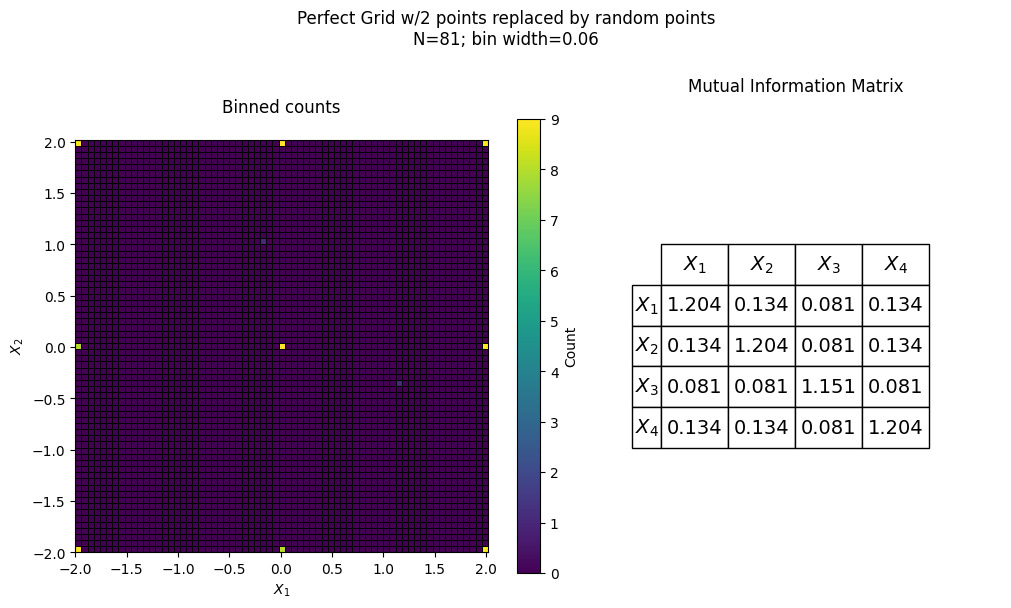

In [ ]:
# Set up a side-by-side Matplotlib layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

# --- Left Subplot: The Graph ---
im = ax1.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Count')
ax1.set_title("Binned counts", pad=20)
ax1.pcolormesh(x_edges, y_edges, counts.T, edgecolors="black", linewidth=0.5)
# --- Right Subplot: The Matrix ---
# Hide the axes lines, ticks, and labels since we only want to show text
ax2.axis("off")

# Render the LaTeX matrix string directly in the center of the subplot
table = ax2.table(
    cellText=[[f"{value:.3f}" for value in row] for row in recomputed],
    rowLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    colLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    cellLoc="center",
    loc="center",
)
table.scale(0.65, 2.5)
table.auto_set_font_size(False)
table.set_fontsize(14)
ax2.set_title("Mutual Information Matrix", pad=20)
fig.suptitle("Perfect Grid w/2 points replaced by random points\nN=81; bin width=0.06\n")

plt.savefig(MI_path + "/histogram_and_mi_matrix_grid_2replacements_0p06.pdf", bbox_inches="tight")

\
\
\
\
Grid w/2 additions
\
\
\
\

In [ ]:
name = ["grid_add_2"]
sampling_mode = ["grid_additions"]
shuffle_frac = [None]
jitter_frac = [None]
iid_frac = [None]
num_grids = [None]
num_removed = [None]
add_iid = [2]
seed=0
n = 81

dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            sampling_mode=sampling_mode[0],
            shuffle_frac=shuffle_frac[0],
            seed=seed,
            jitter_frac=jitter_frac[0],
            iid_frac = iid_frac[0],
            num_grids=num_grids[0],
            num_removed=num_removed[0],
            add_iid=add_iid[0],
        )

X, _ = dataset.get_all_data()
X_np = X.numpy()

saved = np.load(MI_path + f"/mi_matrices/{name[0]}_samples_{n}_seed_{seed}_mi.npz")
bin_edges = saved["edges_bw_0p06"]

counts, x_edges, y_edges = np.histogram2d(
    X_np[:, 0],
    X_np[:, 1],
    bins=[bin_edges, bin_edges],
)

Random points generated: [[ 0.54784675 -0.92085314 -1.8361059  -1.93388946]
 [ 1.25308096  1.65102231  0.4265431   0.91798624]]

Grid points: 81, added iid points: 2, total points: 83


In [ ]:
recomputed = binned_mi_summary(
    X_np,
    bin_edges,
)["matrix"]

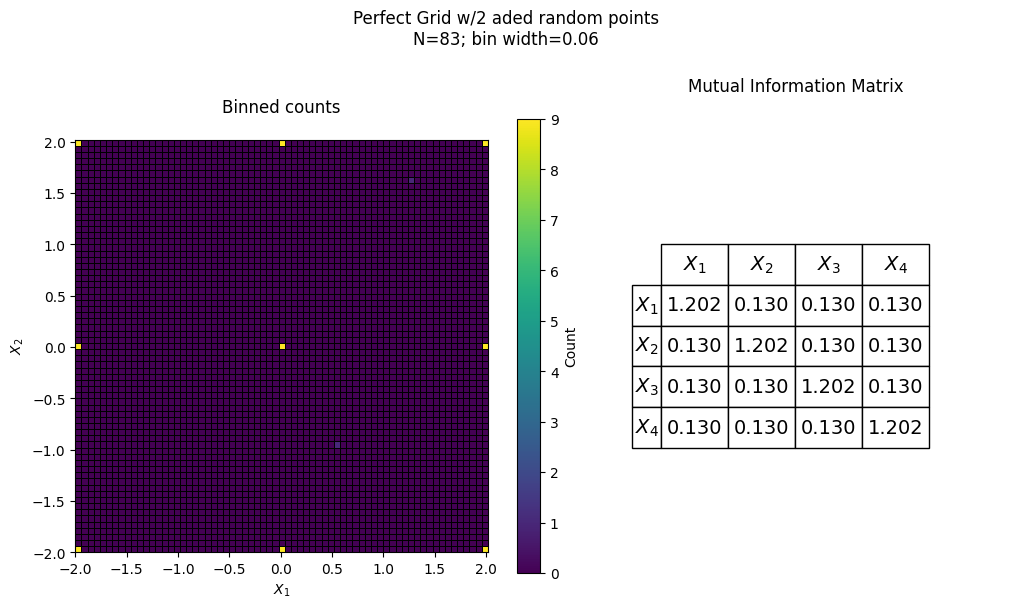

In [ ]:
# Set up a side-by-side Matplotlib layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

# --- Left Subplot: The Graph ---
im = ax1.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Count')
ax1.set_title("Binned counts", pad=20)
ax1.pcolormesh(x_edges, y_edges, counts.T, edgecolors="black", linewidth=0.5)
# --- Right Subplot: The Matrix ---
# Hide the axes lines, ticks, and labels since we only want to show text
ax2.axis("off")

# Render the LaTeX matrix string directly in the center of the subplot
table = ax2.table(
    cellText=[[f"{value:.3f}" for value in row] for row in recomputed],
    rowLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    colLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    cellLoc="center",
    loc="center",
)
table.scale(0.65, 2.5)
table.auto_set_font_size(False)
table.set_fontsize(14)
ax2.set_title("Mutual Information Matrix", pad=20)
fig.suptitle("Perfect Grid w/2 aded random points\nN=83; bin width=0.06\n")

plt.savefig(MI_path + "/histogram_and_mi_matrix_grid_2additions_0p06.pdf", bbox_inches="tight")

Mod construction n=1089

In [ ]:
name = ["mi_modulo_q_33"]
sampling_mode = ["mi_modular"]
shuffle_frac = [None]
jitter_frac = [None]
iid_frac = [None]
num_grids = [None]
num_removed = [None]
add_iid = [None]
mi_mod_levels=33
seed=0
n = 1089

dataset = GeneralDataset(
            encode_num=4,
            num_samples=n,
            mean=0,
            std_dev=2,
            sampling_mode=sampling_mode[0],
            shuffle_frac=shuffle_frac[0],
            seed=seed,
            jitter_frac=jitter_frac[0],
            iid_frac = iid_frac[0],
            num_grids=num_grids[0],
            num_removed=num_removed[0],
            add_iid=add_iid[0],
            mi_mod_levels=33
        )

X, _ = dataset.get_all_data()
X_np = X.numpy()

MI_path = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-29/exp27_MI_TC_adv_mod_tests_large_N"

saved = np.load(MI_path + f"/mi_matrices/{name[0]}_samples_{n}_seed_{seed}_mi.npz")
bin_edges = saved["edges_bw_0p06"]

counts, x_edges, y_edges = np.histogram2d(
    X_np[:, 0],
    X_np[:, 1],
    bins=[bin_edges, bin_edges],
)

Generated dataset with 1089 samples.


In [ ]:
recomputed = binned_mi_summary(
    X_np,
    bin_edges,
)["matrix"]

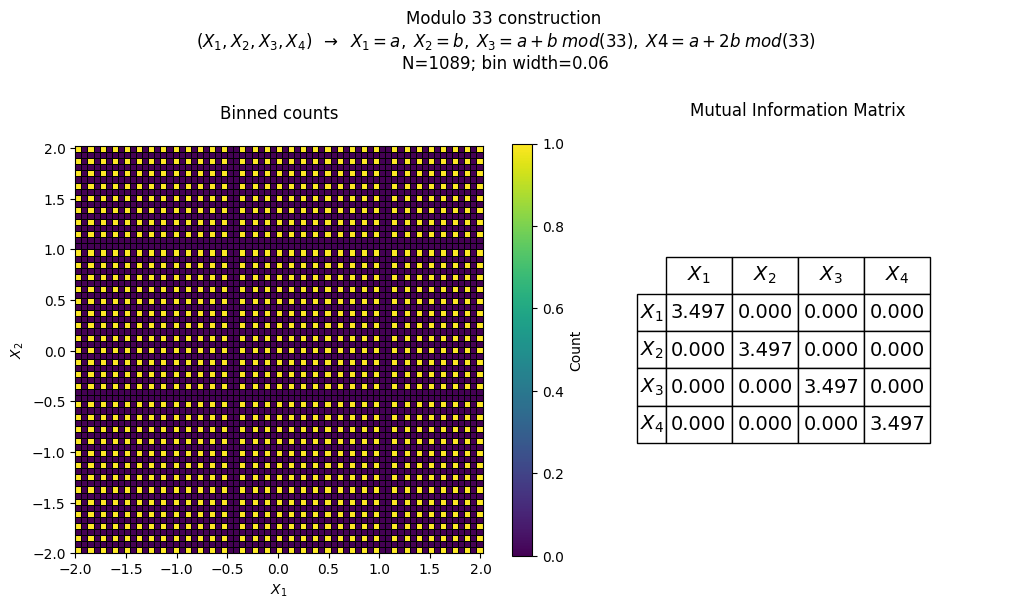

In [ ]:
# Set up a side-by-side Matplotlib layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), constrained_layout=True)

# --- Left Subplot: The Graph ---
im = ax1.imshow(
    counts.T,
    origin="lower",
    aspect="equal",
    extent=[
        x_edges[0],
        x_edges[-1],
        y_edges[0],
        y_edges[-1],
    ],
)

ax1.set_xlabel(r"$X_1$")
ax1.set_ylabel(r"$X_2$")
cbar = fig.colorbar(im, ax=ax1)
cbar.set_label('Count')
ax1.set_title("Binned counts", pad=20)
ax1.pcolormesh(x_edges, y_edges, counts.T, edgecolors="black", linewidth=0.5)
# --- Right Subplot: The Matrix ---
# Hide the axes lines, ticks, and labels since we only want to show text
ax2.axis("off")

# Render the LaTeX matrix string directly in the center of the subplot
table = ax2.table(
    cellText=[[f"{value:.3f}" for value in row] for row in recomputed],
    rowLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    colLabels=[r"$X_1$", r"$X_2$", r"$X_3$", r"$X_4$"],
    cellLoc="center",
    loc="center",
)
table.scale(0.65, 2.5)
table.auto_set_font_size(False)
table.set_fontsize(14)
ax2.set_title("Mutual Information Matrix", pad=20)
fig.suptitle("Modulo 33 construction \n" + r"$(X_1, X_2, X_3, X_4) \;\;\rightarrow\;\; X_1 = a, \; X_2 = b, \; X_3 = a + b \;mod(33), \; X4 = a + 2b \;mod (33)$" + "\nN=1089; bin width=0.06\n")

plt.savefig(MI_path + "/histogram_and_mi_matrix_mi_mod_33.pdf", bbox_inches="tight")

\
\
\
**Jitter vs Mean MI**
\
\
\

In [ ]:
summary_gaps_jitter = pd.read_csv("/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-26/exp23_super_extensive_jitter_sweep_5_seeds/summary.csv")

In [ ]:
path_mi_tests_jitter = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-28/exp25_MI_tests_only_with_jitter"
results_mi_jitter = pd.read_csv(path_mi_tests_jitter + "/results.csv")

results_mi_jitter["jitter_diameter"] = 4*results_mi_jitter["jitter"]

mean_mi_columns = ["mean_mi_bw_0p02", "mean_mi_bw_0p03", "mean_mi_bw_0p04", "mean_mi_bw_0p05", "mean_mi_bw_0p06"]

summary_mi_jitter = (results_mi_jitter
           .groupby("jitter_diameter")[mean_mi_columns]
           .agg(["mean", "max", "min", "std"])
           .reset_index()
           .sort_values("jitter_diameter"))

#summary_mi_jitter.to_csv(path_mi_tests_jitter + "/summary_mi_jitter.csv")

In [ ]:
cmap_mi = mpl.colormaps.get_cmap("plasma")

bin_colors = {
    0: cmap_mi(0 / 5),
    1: cmap_mi(1 / 5),
    2: cmap_mi(2 / 5),
    3: cmap_mi(4 / 5),
    4: cmap_mi(5 / 5),
}

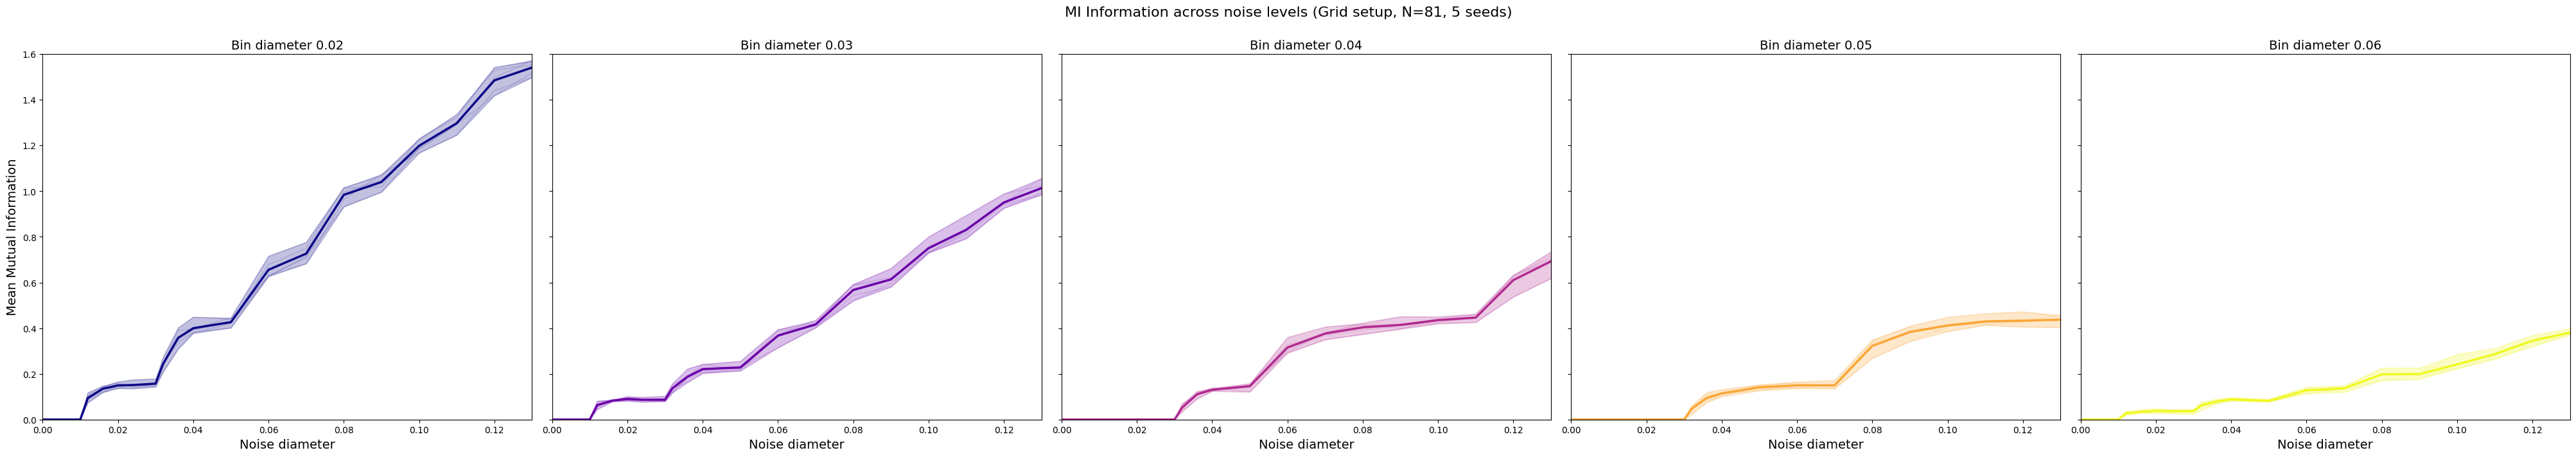

In [ ]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(40, 7),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

x = summary_mi_jitter["jitter_diameter"].to_numpy()

for i, (ax, layer) in enumerate(zip(axes, mean_mi_columns)):
    color = bin_colors[i]

    for seed, seed_df in results_mi_jitter.groupby("seed"):
        seed_df = seed_df.sort_values("jitter_diameter")

        ax.plot(
            seed_df["jitter_diameter"],
            seed_df[layer],
            color=color,
            alpha=0.15,
            linewidth=1
        )

    ax.fill_between(
        x,
        summary_mi_jitter[layer]["min"].to_numpy(),
        summary_mi_jitter[layer]["max"].to_numpy(),
        color=color,
        alpha=0.25
    )

    ax.plot(
        x,
        summary_mi_jitter[layer]["mean"].to_numpy(),
        color=color,
        linewidth=2.5
    )

    ax.set_title(f"Bin diameter 0.{layer[len(layer)-2:len(layer)+1]}", size = 14)
    ax.set_xlabel("Noise diameter", size = 14)
    ax.set_xlim(0, 0.13)
    ax.set_ylim(0, 1.6)

axes[0].set_ylabel("Mean Mutual Information", size = 14)
fig.suptitle("MI Information across noise levels (Grid setup, N=81, 5 seeds)\n", size = 16)

fig.savefig(
    path_mi_tests_jitter + "/MI_variation_across_noise_5runs.pdf",
    bbox_inches="tight"
)

\
\
\
\
**4th gaps vs TC vs sample size**
\
\
\
\

In [ ]:
path_iid_TC = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-06-30"
results_small_n = pd.read_csv(path_iid_TC + "/exp28_MI_TC_iid_tests_various_sizes_redo/results.csv")
results_large_n = pd.read_csv(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/results.csv")
results_overall = pd.concat([results_small_n, results_large_n])

gap_columns = ["4th_gap_layer0", "4th_gap_layer1", "4th_gap_layer2", "max_EV_layer3"]

summary_small_n_mean_eigengaps = (results_small_n
           .groupby("n")[gap_columns]
           .agg(["mean", "max", "min", "std"])
           .reset_index()
           .sort_values("n"))

TC_columns = ["TC_bw_0p02","TC_bw_0p03","TC_bw_0p04","TC_bw_0p05","TC_bw_0p06"]

summary_all_n_mean_TC = (results_overall
           .groupby("n")[TC_columns]
           .agg(["mean", "max", "min", "std"])
           .reset_index()
           .sort_values("n"))

summary_small_n_mean_eigengaps.to_csv(path_iid_TC + "/exp28_MI_TC_iid_tests_various_sizes_redo/summary_small_n_mean_eigengaps.csv")
summary_all_n_mean_TC.to_csv(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/summary_all_n_mean_TC.csv")

In [ ]:
summary_joined_meanTC_meanGap = pd.merge(summary_small_n_mean_eigengaps, summary_all_n_mean_TC, on="n")

/tmp/ipykernel_3299/147157923.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  summary_joined_meanTC_meanGap = pd.merge(summary_small_n_mean_eigengaps, summary_all_n_mean_TC, on="n")


In [ ]:
summary_joined_meanTC_meanGap

n 4th_gap_layer0                               4th_gap_layer1            \
                  mean       max       min       std           mean       max   
0     9       0.035339  0.075058  0.010043  0.025237       0.006229  0.010369   
1    16       0.131732  0.193858  0.080346  0.041165       0.007845  0.017460   
2    54       0.337502  0.423958  0.237257  0.067735       0.129175  0.164690   
3    81       0.360441  0.448991  0.251833  0.088572       0.172764  0.256213   
4   169       0.631227  0.665023  0.605669  0.028463       0.389580  0.450918   
5   256       0.739088  0.800174  0.681210  0.048517       0.462728  0.501139   
6   289       0.751712  0.830859  0.653893  0.072542       0.514025  0.546673   
7   625       0.796949  0.898892  0.625686  0.105137       0.591155  0.701656   
8  1089       0.851598  0.900788  0.812007  0.039796       0.578937  0.596183   

                      4th_gap_layer2  ... TC_bw_0p04           TC_bw_0p05  \
        min       std           mean  ...        min       std       mean   
0  0.001451  0.003213       0.009695  ...   6.129576  0.200834   6.376028   
1  0.002506  0.005729       0.011987  ...   7.711262  0.127075   7.732839   
2  0.082894  0.029921       0.111781  ...  10.528812  0.043815  10.202179   
3  0.089672  0.065715       0.189975  ...  11.135034  0.133812  10.928699   
4  0.303857  0.055078       0.420839  ...  11.873844  0.053148  11.353147   
5  0.422213  0.032114       0.417844  ...  11.957531  0.041748  11.317756   
6  0.477539  0.029873       0.491136  ...  11.925765  0.048356  11.278823   
7  0.509957  0.077849       0.639881  ...  11.630794  0.028102  10.817283   
8  0.553606  0.015872       0.549675  ...  11.243223  0.006947  10.392116   

                                  TC_bw_0p06                                  
         max        min       std       mean        max        min       std  
0   6.591674   5.975543  0.233602   6.376028   6.591674   6.129576  0.175624  
1   8.025133   7.505273  0.186158   7.698181   8.144479   7.331986  0.293648  
2  10.251429  10.139051  0.055719   9.979617  10.235447   9.772847  0.175842  
3  11.047530  10.813529  0.092562  10.468436  10.593822  10.355512  0.114696  
4  11.455523  11.309881  0.059270  10.786028  10.805333  10.759225  0.019021  
5  11.341541  11.303374  0.015353  10.725707  10.778734  10.664862  0.041518  
6  11.364970  11.238732  0.049679  10.650222  10.706767  10.576780  0.048469  
7  10.855618  10.793609  0.027368  10.155249  10.188761  10.133245  0.020458  
8  10.402571  10.371277  0.012745   9.696690   9.710116   9.689105  0.008038  

[9 rows x 37 columns]

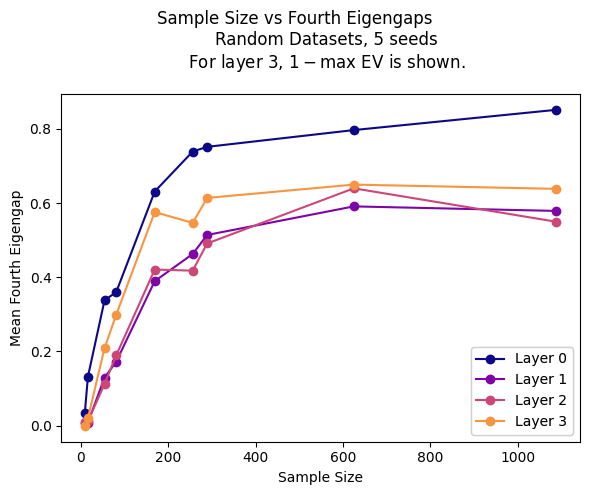

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("plasma")
layer_colors = {
    0: cmap2(0 / 4),
    1: cmap2(1 / 4),
    2: cmap2(2 / 4),
    3: cmap2(3 / 4),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Fourth Eigengap")

layer0_line, = ax.plot(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer0"]["mean"], marker="o", color=layer_colors[0], label="Layer 0")
layer1_line, = ax.plot(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer1"]["mean"], marker="o", color=layer_colors[1], label="Layer 1")
layer2_line, = ax.plot(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer2"]["mean"], marker="o", color=layer_colors[2], label="Layer 2")
layer3_line, = ax.plot(summary_small_n_mean_eigengaps["n"], 1-summary_small_n_mean_eigengaps["max_EV_layer3"]["mean"], marker="o", color=layer_colors[3], label="Layer 3")

first_legend = ax.legend(handles=[layer0_line, layer1_line, layer2_line, layer3_line],
                         loc='lower right',
                        )
ax.add_artist(first_legend)

# corr_coefficient0, p_value0 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer0"]["mean"])
# corr_coefficient1, p_value1 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer1"]["mean"])
# corr_coefficient2, p_value2 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer2"]["mean"])
# corr_coefficient3, p_value3 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["max_EV_layer3"]["mean"])

# text_patch_1 = mpatches.Patch(color="none", label=f"Layer 0:{corr_coefficient0:.3f}\nLayer 1:{corr_coefficient1:.3f}\nLayer 2:{corr_coefficient2:.3f}\nLayer 3:{corr_coefficient3:.3f}")
# ax.legend(handles=[text_patch_1],
#           loc='lower center',
#           bbox_to_anchor=(1.0, 0.7),
#           handlelength=0,
#           handletextpad=0,
#           title="Correlations"
# )

fig.suptitle(r'''Sample Size vs Fourth Eigengaps
            Random Datasets, 5 seeds
            For layer 3, $1 - $max EV is shown.''')
plt.tight_layout()

plt.savefig(path_iid_TC + "/exp28_MI_TC_iid_tests_various_sizes_redo/Samplesize_vs_gaps_small_n.pdf", bbox_inches="tight")

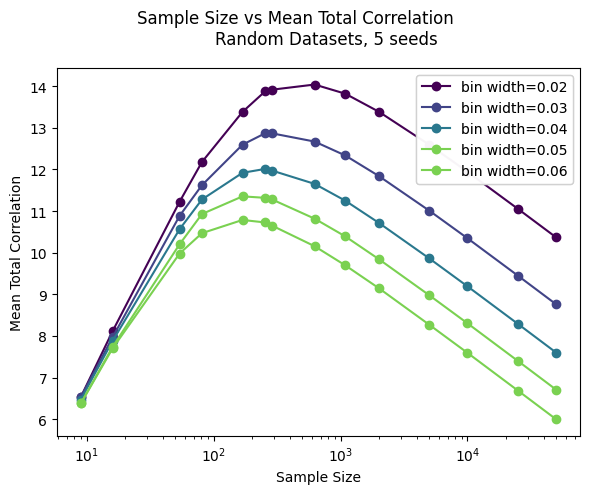

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Total Correlation")
ax.set_xscale('log')

bin0p02_line, = ax.plot(summary_all_n_mean_TC["n"], summary_all_n_mean_TC["TC_bw_0p02"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.02")
bin0p03_line, = ax.plot(summary_all_n_mean_TC["n"], summary_all_n_mean_TC["TC_bw_0p03"]["mean"], marker="o", color=layer_colors[1], label="bin width=0.03")
bin0p04_line, = ax.plot(summary_all_n_mean_TC["n"], summary_all_n_mean_TC["TC_bw_0p04"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.04")
bin0p05_line, = ax.plot(summary_all_n_mean_TC["n"], summary_all_n_mean_TC["TC_bw_0p05"]["mean"], marker="o", color=layer_colors[3], label="bin width=0.05")
bin0p06_line, = ax.plot(summary_all_n_mean_TC["n"], summary_all_n_mean_TC["TC_bw_0p06"]["mean"], marker="o", color=layer_colors[3], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p02_line, bin0p03_line, bin0p04_line, bin0p05_line, bin0p06_line],
                         loc='upper right',
                        )
ax.add_artist(first_legend)

# corr_coefficient0, p_value0 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer0"]["mean"])
# corr_coefficient1, p_value1 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer1"]["mean"])
# corr_coefficient2, p_value2 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer2"]["mean"])
# corr_coefficient3, p_value3 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["max_EV_layer3"]["mean"])

# text_patch_1 = mpatches.Patch(color="none", label=f"Layer 0:{corr_coefficient0:.3f}\nLayer 1:{corr_coefficient1:.3f}\nLayer 2:{corr_coefficient2:.3f}\nLayer 3:{corr_coefficient3:.3f}")
# ax.legend(handles=[text_patch_1],
#           loc='lower center',
#           bbox_to_anchor=(1.0, 0.7),
#           handlelength=0,
#           handletextpad=0,
#           title="Correlations"
# )

fig.suptitle(r'''Sample Size vs Mean Total Correlation
            Random Datasets, 5 seeds''')
plt.tight_layout()

plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

In [ ]:
summary_TC_sorted = summary_joined_meanTC_meanGap.sort_values(by=('TC_bw_0p06', 'mean'))

In [ ]:
summary_TC_sorted

n 4th_gap_layer0                               4th_gap_layer1            \
                  mean       max       min       std           mean       max   
0     9       0.035339  0.075058  0.010043  0.025237       0.006229  0.010369   
1    16       0.131732  0.193858  0.080346  0.041165       0.007845  0.017460   
8  1089       0.851598  0.900788  0.812007  0.039796       0.578937  0.596183   
2    54       0.337502  0.423958  0.237257  0.067735       0.129175  0.164690   
7   625       0.796949  0.898892  0.625686  0.105137       0.591155  0.701656   
3    81       0.360441  0.448991  0.251833  0.088572       0.172764  0.256213   
6   289       0.751712  0.830859  0.653893  0.072542       0.514025  0.546673   
5   256       0.739088  0.800174  0.681210  0.048517       0.462728  0.501139   
4   169       0.631227  0.665023  0.605669  0.028463       0.389580  0.450918   

                      4th_gap_layer2  ... TC_bw_0p04           TC_bw_0p05  \
        min       std           mean  ...        min       std       mean   
0  0.001451  0.003213       0.009695  ...   6.129576  0.200834   6.376028   
1  0.002506  0.005729       0.011987  ...   7.711262  0.127075   7.732839   
8  0.553606  0.015872       0.549675  ...  11.243223  0.006947  10.392116   
2  0.082894  0.029921       0.111781  ...  10.528812  0.043815  10.202179   
7  0.509957  0.077849       0.639881  ...  11.630794  0.028102  10.817283   
3  0.089672  0.065715       0.189975  ...  11.135034  0.133812  10.928699   
6  0.477539  0.029873       0.491136  ...  11.925765  0.048356  11.278823   
5  0.422213  0.032114       0.417844  ...  11.957531  0.041748  11.317756   
4  0.303857  0.055078       0.420839  ...  11.873844  0.053148  11.353147   

                                  TC_bw_0p06                                  
         max        min       std       mean        max        min       std  
0   6.591674   5.975543  0.233602   6.376028   6.591674   6.129576  0.175624  
1   8.025133   7.505273  0.186158   7.698181   8.144479   7.331986  0.293648  
8  10.402571  10.371277  0.012745   9.696690   9.710116   9.689105  0.008038  
2  10.251429  10.139051  0.055719   9.979617  10.235447   9.772847  0.175842  
7  10.855618  10.793609  0.027368  10.155249  10.188761  10.133245  0.020458  
3  11.047530  10.813529  0.092562  10.468436  10.593822  10.355512  0.114696  
6  11.364970  11.238732  0.049679  10.650222  10.706767  10.576780  0.048469  
5  11.341541  11.303374  0.015353  10.725707  10.778734  10.664862  0.041518  
4  11.455523  11.309881  0.059270  10.786028  10.805333  10.759225  0.019021  

[9 rows x 37 columns]

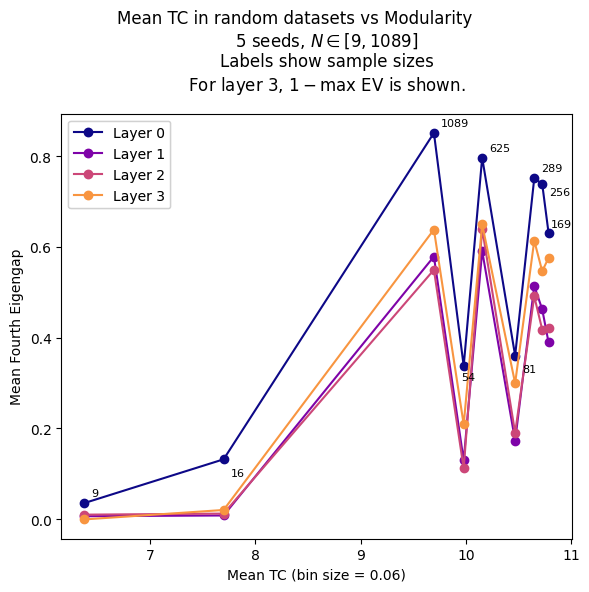

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("plasma")
layer_colors = {
    0: cmap2(0 / 4),
    1: cmap2(1 / 4),
    2: cmap2(2 / 4),
    3: cmap2(3 / 4),
}

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlabel("Mean TC (bin size = 0.06)")
ax.set_ylabel("Mean Fourth Eigengap")

layer0_line, = ax.plot(summary_TC_sorted["TC_bw_0p06"]["mean"], summary_TC_sorted["4th_gap_layer0"]["mean"], marker="o", color=layer_colors[0], label="Layer 0")
layer1_line, = ax.plot(summary_TC_sorted["TC_bw_0p06"]["mean"], summary_TC_sorted["4th_gap_layer1"]["mean"], marker="o", color=layer_colors[1], label="Layer 1")
layer2_line, = ax.plot(summary_TC_sorted["TC_bw_0p06"]["mean"], summary_TC_sorted["4th_gap_layer2"]["mean"], marker="o", color=layer_colors[2], label="Layer 2")
layer3_line, = ax.plot(summary_TC_sorted["TC_bw_0p06"]["mean"], 1-summary_TC_sorted["max_EV_layer3"]["mean"], marker="o", color=layer_colors[3], label="Layer 3")

first_legend = ax.legend(handles=[layer0_line, layer1_line, layer2_line, layer3_line],
                         loc='upper left',
                        )
ax.add_artist(first_legend)

# corr_coefficient0, p_value0 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer0"]["mean"])
# corr_coefficient1, p_value1 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer1"]["mean"])
# corr_coefficient2, p_value2 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["4th_gap_layer2"]["mean"])
# corr_coefficient3, p_value3 = pearsonr(summary_small_n_mean_eigengaps["n"], summary_small_n_mean_eigengaps["max_EV_layer3"]["mean"])

# text_patch_1 = mpatches.Patch(color="none", label=f"Layer 0:{corr_coefficient0:.3f}\nLayer 1:{corr_coefficient1:.3f}\nLayer 2:{corr_coefficient2:.3f}\nLayer 3:{corr_coefficient3:.3f}")
# ax.legend(handles=[text_patch_1],
#           loc='lower center',
#           bbox_to_anchor=(1.0, 0.7),
#           handlelength=0,
#           handletextpad=0,
#           title="Correlations"
# )

#Label points
offsets = [
    (5, 5),
    (5, -12),
    (5, 5),
    (-2, -10),
    (5, 5),
    (5, -12),
    (5, 5),
    (5, -8),
    (2, 4),
]

for n, x, y, offset in zip(summary_TC_sorted["n"], summary_TC_sorted["TC_bw_0p06"]["mean"], summary_TC_sorted["4th_gap_layer0"]["mean"], offsets):
    ax.annotate(
        f"{n}",
        xy=(x, y),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
    )

fig.suptitle(r'''Mean TC in random datasets vs Modularity
            5 seeds, $N\in [9, 1089]$
            Labels show sample sizes
            For layer 3, $1 - $max EV is shown.''')
plt.tight_layout()

plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/TC_vs_gaps_iid.pdf", bbox_inches="tight")

\
\
\
Graph behavior of metrics with increasing sample sizes in iid datasets
\
\
\

In [ ]:
path_metrics_iid = "/content/drive/MyDrive/MSRP/modularity_experiments/modularisation_via_noise/results_nonlinear/2026-07-13/exp32_metrics_iid_n_5_to_255"
various_metrics_results_iid = pd.read_csv(path_metrics_iid + "/results.csv")

metrics_columns = ["mean_abs_corr",
           "mean_mi_bw_0p03",
           "mean_nmi_arith_bw_0p03",
           "mean_nmi_joint_bw_0p03",
           "mean_adj_mi_bw_0p03",
           "TC_bw_0p03",
           "Norm_TC_bw_0p03",
           "mean_occupied_bins_bw_0p03",
           "mean_samples_per_occupied_bin_bw_0p03",
           "mean_mi_bw_0p06",
           "mean_nmi_arith_bw_0p06",
           "mean_nmi_joint_bw_0p06",
           "mean_adj_mi_bw_0p06",
           "TC_bw_0p06",
           "Norm_TC_bw_0p06",
           "mean_occupied_bins_bw_0p06",
           "mean_samples_per_occupied_bin_bw_0p06",
           "mean_ksg_mi_neigh_3",
           "mean_ksg_mi_neigh_5",
           "mean_ksg_mi_neigh_7",
           ]

summary_metrics_iid = (various_metrics_results_iid
           .groupby("n")[metrics_columns]
           .agg(["mean", "max", "min", "std"])
           .reset_index()
           .sort_values("n"))

summary_metrics_iid.to_csv(path_metrics_iid + "/summary_metrics_results_iid.csv")

In [ ]:
summary_metrics_iid

n mean_abs_corr                               mean_mi_bw_0p03            \
                 mean       max       min       std            mean       max   
0     5      0.407848  0.521328  0.210625  0.084093        1.572164  1.609438   
1    15      0.206707  0.368520  0.048435  0.082782        2.574608  2.708050   
2    25      0.172512  0.264936  0.084024  0.057015        2.983335  3.080246   
3    35      0.144818  0.226132  0.092382  0.039062        3.225220  3.357306   
4    45      0.124874  0.180642  0.069214  0.033022        3.379471  3.508186   
5    55      0.112190  0.172262  0.062354  0.033903        3.487714  3.619739   
6    65      0.103974  0.165969  0.056765  0.031533        3.570766  3.702358   
7    75      0.092012  0.148419  0.038352  0.030470        3.620345  3.753140   
8    85      0.089547  0.141449  0.033634  0.027160        3.666312  3.790118   
9    95      0.085993  0.159035  0.036334  0.032475        3.690521  3.779041   
10  105      0.081704  0.135143  0.027587  0.028274        3.708517  3.772274   
11  115      0.075771  0.121693  0.040854  0.020943        3.731812  3.795859   
12  125      0.070544  0.113995  0.046139  0.018069        3.741211  3.790551   
13  135      0.068018  0.099114  0.043219  0.016622        3.741600  3.793840   
14  145      0.064189  0.086424  0.031500  0.017054        3.748138  3.807136   
15  155      0.060787  0.090703  0.031806  0.017245        3.745258  3.804267   
16  165      0.059629  0.092730  0.033254  0.015880        3.741912  3.821912   
17  175      0.060605  0.094177  0.041472  0.018229        3.736076  3.819582   
18  185      0.056462  0.087869  0.028382  0.018294        3.729417  3.805538   
19  195      0.055774  0.080916  0.026726  0.015261        3.721384  3.809340   
20  205      0.054915  0.082710  0.031454  0.014643        3.713052  3.796051   
21  215      0.056876  0.079982  0.028297  0.015435        3.703591  3.781119   
22  225      0.055179  0.079375  0.027167  0.013861        3.693826  3.761464   
23  235      0.054913  0.078139  0.030274  0.013233        3.682260  3.757895   
24  245      0.053975  0.081588  0.028764  0.012986        3.667851  3.728615   
25  255      0.051507  0.084421  0.021910  0.013906        3.654013  3.695755   

                       mean_nmi_arith_bw_0p03  ... mean_ksg_mi_neigh_3  \
         min       std                   mean  ...                 min   
0   1.279854  0.096499               0.986330  ...            0.000000   
1   2.442118  0.070590               0.974301  ...            0.000000   
2   2.903426  0.050528               0.961822  ...            0.000648   
3   3.111307  0.067315               0.951177  ...            0.007224   
4   3.178224  0.076946               0.940398  ...            0.003938   
5   3.274390  0.079543               0.930603  ...            0.010147   
6   3.371509  0.071982               0.922057  ...            0.002730   
7   3.481808  0.064076               0.912282  ...            0.000949   
8   3.505264  0.070592               0.904431  ...            0.000396   
9   3.551383  0.063013               0.895526  ...            0.001286   
10  3.606695  0.045451               0.887276  ...            0.000699   
11  3.613408  0.041338               0.880844  ...            0.000000   
12  3.647214  0.034014               0.873571  ...            0.000000   
13  3.650655  0.032373               0.865913  ...            0.001404   
14  3.658735  0.036890               0.859714  ...            0.000022   
15  3.662096  0.036237               0.852838  ...            0.001970   
16  3.638235  0.042168               0.846391  ...            0.000000   
17  3.612272  0.041143               0.840082  ...            0.002057   
18  3.615627  0.036463               0.834044  ...            0.000000   
19  3.616964  0.038679               0.828173  ...            0.000995   
20  3.619021  0.037803               0.822536  ...            0.004179   
21  3.619052  0.034208             

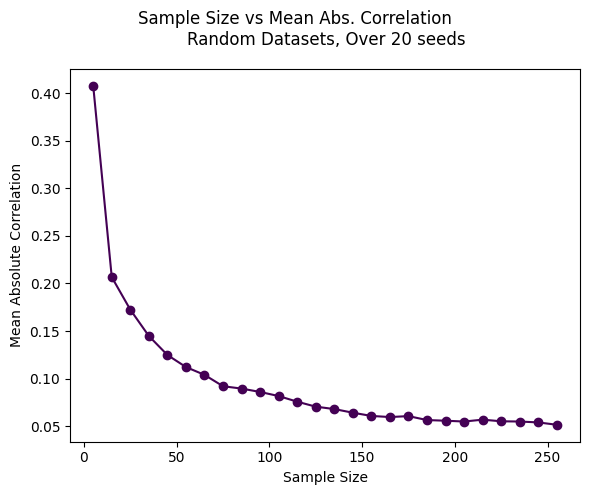

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0),
    1: cmap2(1),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Absolute Correlation")
#ax.set_xscale('log')

mac_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_abs_corr"]["mean"], marker="o", color=layer_colors[0])

fig.suptitle(r'''Sample Size vs Mean Abs. Correlation
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

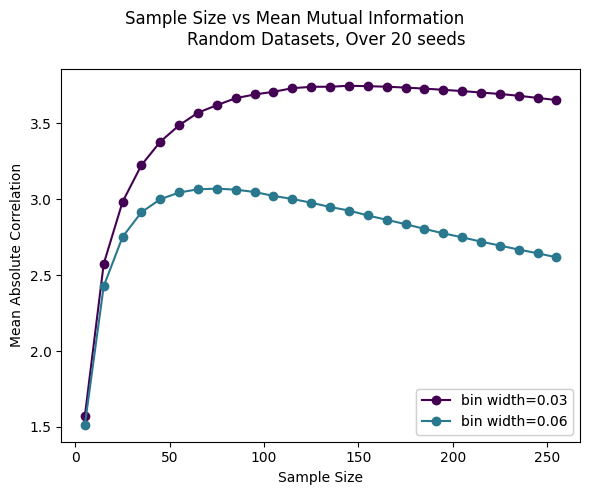

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Absolute Correlation")
#ax.set_xscale('log')

bin0p03_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_mi_bw_0p03"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.03")
bin0p06_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_mi_bw_0p06"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p03_line, bin0p06_line],
                         loc="lower right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs Mean Mutual Information
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

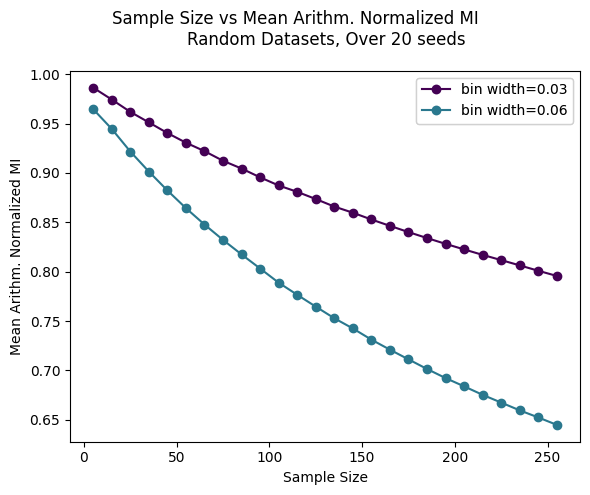

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Arithm. Normalized MI")
#ax.set_xscale('log')

bin0p03_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_nmi_arith_bw_0p03"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.03")
bin0p06_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_nmi_arith_bw_0p06"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p03_line, bin0p06_line],
                         loc="upper right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs Mean Arithm. Normalized MI
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

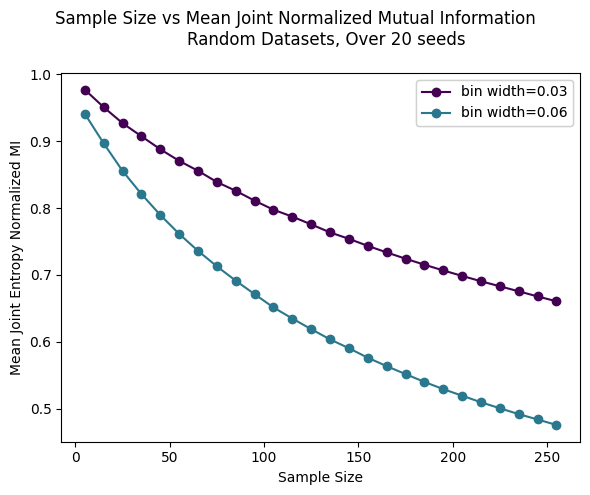

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Joint Entropy Normalized MI")
#ax.set_xscale('log')

bin0p03_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_nmi_joint_bw_0p03"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.03")
bin0p06_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_nmi_joint_bw_0p06"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p03_line, bin0p06_line],
                         loc="upper right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs Mean Joint Normalized Mutual Information
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

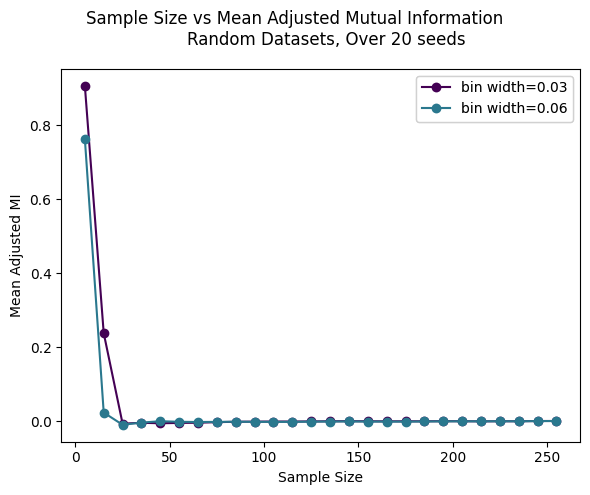

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Adjusted MI")
#ax.set_xscale('log')

bin0p03_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_adj_mi_bw_0p03"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.03")
bin0p06_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_adj_mi_bw_0p06"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p03_line, bin0p06_line],
                         loc="upper right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs Mean Adjusted Mutual Information
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

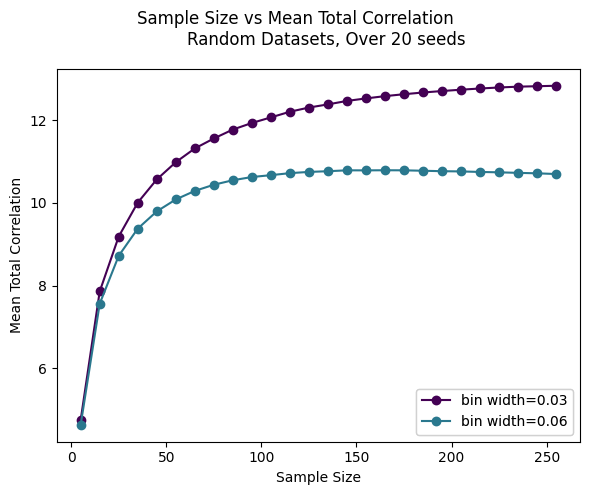

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Total Correlation")
#ax.set_xscale('log')

bin0p03_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["TC_bw_0p03"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.03")
bin0p06_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["TC_bw_0p06"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p03_line, bin0p06_line],
                         loc="lower right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs Mean Total Correlation
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

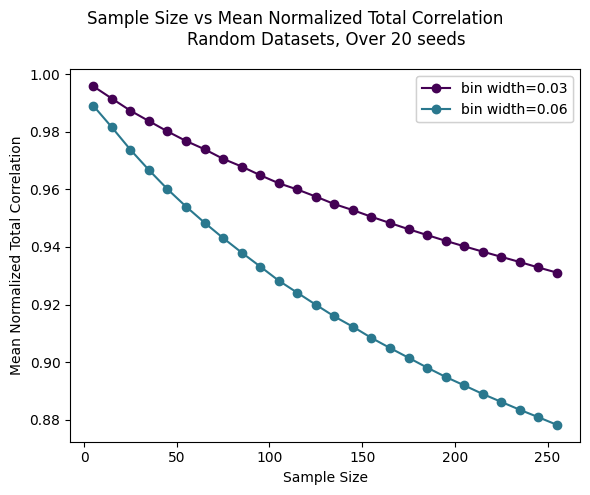

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean Normalized Total Correlation")
#ax.set_xscale('log')

bin0p03_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["Norm_TC_bw_0p03"]["mean"], marker="o", color=layer_colors[0], label="bin width=0.03")
bin0p06_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["Norm_TC_bw_0p06"]["mean"], marker="o", color=layer_colors[2], label="bin width=0.06")

first_legend = ax.legend(handles=[bin0p03_line, bin0p06_line],
                         loc="upper right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs Mean Normalized Total Correlation
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

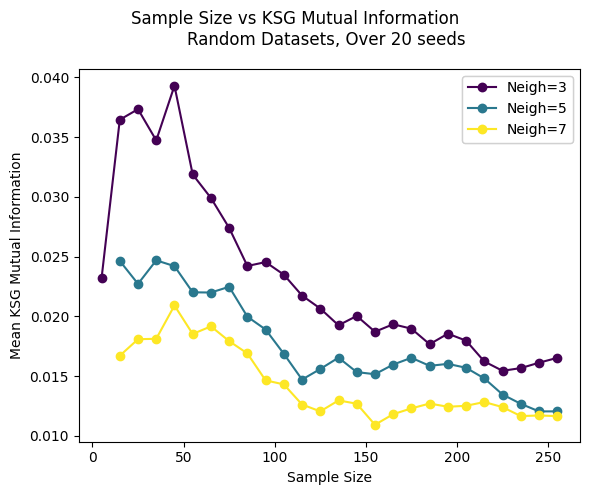

In [ ]:
import matplotlib.patches as mpatches
from scipy.stats import pearsonr

cmap2 = mpl.colormaps.get_cmap("viridis")
layer_colors = {
    0: cmap2(0 / 5),
    1: cmap2(1 / 5),
    2: cmap2(2 / 5),
    3: cmap2(4 / 5),
    4: cmap2(5 / 5),
}

fig, ax = plt.subplots(figsize=(6, 5))

ax.set_xlabel("Sample Size")
ax.set_ylabel("Mean KSG Mutual Information")
#ax.set_xscale('log')

neigh3_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_ksg_mi_neigh_3"]["mean"], marker="o", color=layer_colors[0], label="Neigh=3")
neigh5_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_ksg_mi_neigh_5"]["mean"], marker="o", color=layer_colors[2], label="Neigh=5")
neigh7_line, = ax.plot(summary_metrics_iid["n"], summary_metrics_iid["mean_ksg_mi_neigh_7"]["mean"], marker="o", color=layer_colors[4], label="Neigh=7")

first_legend = ax.legend(handles=[neigh3_line, neigh5_line, neigh7_line],
                         loc="upper right",
                        )
ax.add_artist(first_legend)

fig.suptitle(r'''Sample Size vs KSG Mutual Information
            Random Datasets, Over 20 seeds''')
plt.tight_layout()

#plt.savefig(path_iid_TC + "/exp29_MI_TC_measurements_only_large_n_iid/Sample_size_vs_TC_all_iid.pdf", bbox_inches="tight")

Here is the corr matrix for n=25


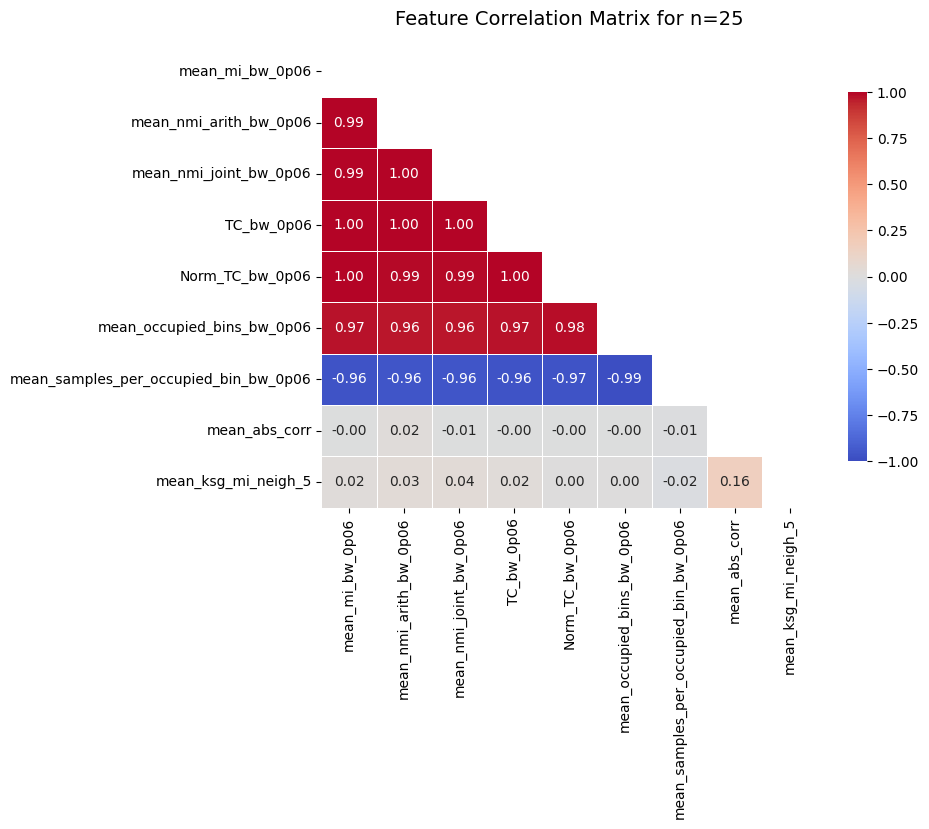

Here is the corr matrix for n=75


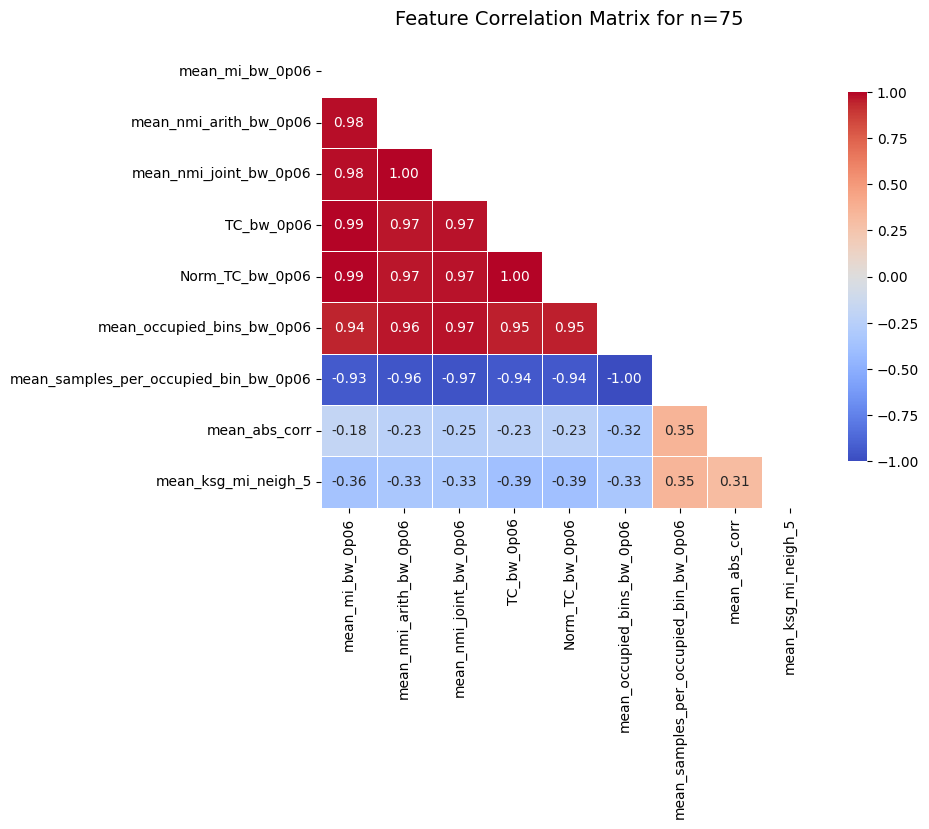

Here is the corr matrix for n=165


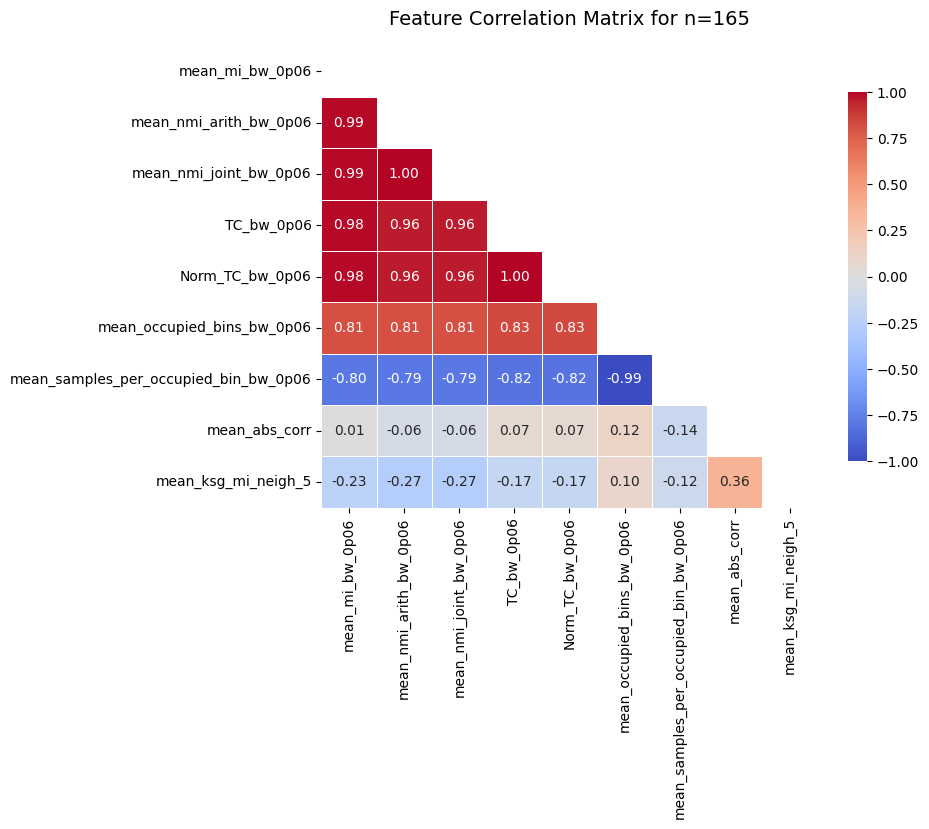

Here is the corr matrix for n=255


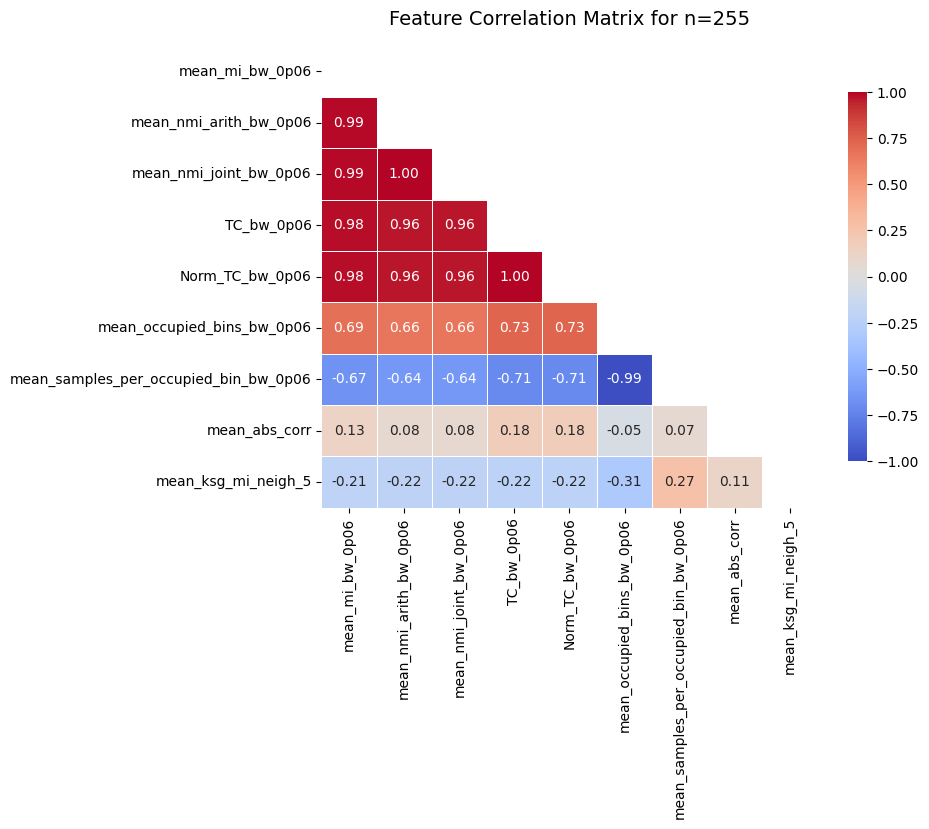

In [ ]:
import seaborn as sns

chosen_n = [25, 75, 165, 255]

for num in chosen_n:
    metrics_at_n = various_metrics_results_iid[various_metrics_results_iid["n"] == num]

    corr = metrics_at_n[
        [
            "mean_mi_bw_0p06",
            "mean_nmi_arith_bw_0p06",
            "mean_nmi_joint_bw_0p06",
            "TC_bw_0p06",
            "Norm_TC_bw_0p06",
            "mean_occupied_bins_bw_0p06",
            "mean_samples_per_occupied_bin_bw_0p06",
            "mean_abs_corr",
            "mean_ksg_mi_neigh_5",
        ]
    ].corr(method="spearman")

    print(f"Here is the corr matrix for n={num}")

    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 4. Set up the matplotlib figure
    plt.figure(figsize=(8, 6))

    # 5. Plot the nicely formatted heatmap
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,          # Prints correlation values inside the cells
        fmt='.2f',           # Formats numbers to 2 decimal places
        cmap='coolwarm',     # Color map (blue for negative, red for positive)
        vmin=-1, vmax=1,     # Anchors the color scale limits
        linewidths=0.5,      # Adds subtle white lines between cells
        cbar_kws={'shrink': 0.8} # Adjusts color bar size
    )

    plt.title(f'Feature Correlation Matrix for n={num}', fontsize=14, pad=15)
    plt.show()